# Who Gets Boosted, Where, and Who Drives It? Bluesky Starter Pack Exposure

## Problem Statement

Bluesky Starter Packs are designed to help new users quickly discover accounts to follow, but it remains unclear whether they genuinely broaden discovery or instead repeatedly direct attention toward the same small set of highly visible accounts. If recommendations are overly concentrated, newcomers may encounter a narrow slice of the network, shaping early impressions of who is influential while making it harder for emerging or smaller voices to be discovered. At the same time, Starter Packs are user-generated and loosely structured, which makes it difficult to systematically evaluate how attention is distributed or whether repetition reflects genuine community consensus or the influence of a few highly active creators.

## Project Topic

This project examines how attention is distributed through Bluesky Starter Packs by treating pack inclusion as a measurable exposure signal. Specifically, it analyzes how often each account appears across different Starter Packs and evaluates whether exposure is broadly shared or concentrated among a small subset of accounts.

The analysis also compares patterns across pack themes and languages to understand how different topical or linguistic ecosystems shape discovery.

In addition, the project considers the role of creators by examining whether repeated recommendations emerge from many independent curators making similar choices or from a small group of highly active pack creators whose lists disproportionately shape visibility.

## Research Questions

**1. Who Gets Boosted?**
   
   Exposure concentration: To what extent do Starter Packs distribute attention across diverse accounts versus reinforcing visibility around a limited group of highly recommended profiles?

**2. Where?**

Variation across ecosystems: How does exposure inequality differ across pack themes and languages, and where is concentration most pronounced? What patterns emerge between large versus small language communities or between broad versus niche topical ecosystems?

**3. Who Drives it?**

Drivers of repeated recommendation: Is repeated inclusion primarily the result of broadly shared curation norms across many creators, or is it driven by a small number of highly active creators who produce many packs or reuse similar member lists?

**Implications for discovery:** What do these patterns suggest about onboarding fairness, community visibility, and the potential need for more diversity-aware recommendation or curation practices on the platform?

## Data Collection

### Data sources and collection

The raw data comes from publicly accessible Bluesky Starter Pack structures. We use the anonymized Starter Pack datasets provided by the Bluesky Research Datasets project (Balduf et al., 2024), which are constructed from a full-network snapshot and include anonymized creator identifiers and list relationships. Two main datasets were used:

- **Starter Pack metadata** (`starter_packs.parquet`): "https://bsky-data.leobalduf.com/starter_packs.parquet"

This file contains one record per Starter Pack, including pack titles, descriptions, creator identifiers, and list references. These records were generated from previously collected Starter Pack metadata derived from public pack information and associated list identifiers.

- **Starter Pack membership lists** (`list_items.parquet`): "https://bsky-data.leobalduf.com/list_items.parquet"

This file contains the pack membership relationships. Each row represents a connection between a Starter Pack and a member account included in that pack. The membership data was obtained from list-based endpoints, which expose which accounts belong to a given Starter Pack list.

Because these lists are large, they were exported into *Parquet* format to allow scalable processing.

In [1]:
# install dependencies and import libraries
!pip -q install langdetect tqdm

import os
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow.parquet as pq
import pyarrow as pa
from collections import defaultdict
from langdetect import detect, DetectorFactory
from tqdm import tqdm
import time
import requests
import gzip
import shutil

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

tqdm.pandas()  # enable progress bar
DetectorFactory.seed = 0  # make detection reproducible

In [2]:
!pip install atproto --quiet
!pip install selenium webdriver-manager atproto pandas

In [3]:
# helper function: parse JSON-like strings
def maybe_json(x):
    if isinstance(x, str):
        try:
            return json.loads(x)
        except Exception:
            return x
    return x

In [4]:
# helper function: detect language, returns 'unknown' on short/empty text or errors
def detect_language_safe(text):
    """
    From language_column_data.ipynb:
    Returns 'unknown' if text empty/too short or langdetect fails.
    """
    try:
        if not isinstance(text, str) or len(text.strip()) < 2:
            return "unknown"
        return detect(text)
    except Exception:
        return "unknown"

In [5]:
# download the raw Parquet datasets - starter packs metadata and list items membership edges
!curl -L -o starter_packs.parquet "https://bsky-data.leobalduf.com/starter_packs.parquet"
!curl -L -o list_items.parquet "https://bsky-data.leobalduf.com/list_items.parquet"
!ls -lh *.parquet

sp = pd.read_parquet(
    "starter_packs.parquet",
    columns=["did_id", "rkey", "name", "description", "list"]
)

sp["list"] = sp["list"].apply(maybe_json)

ptr = pd.json_normalize(sp["list"])[["did_id", "rkey"]].rename(
    columns={"did_id": "list_did_id", "rkey": "list_rkey"}
)

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 12.8M  100 12.8M    0     0  7470k      0  0:00:01  0:00:01 --:--:-- 7475k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  419M  100  419M    0     0  30.3M      0  0:00:13  0:00:13 --:--:-- 31.2M
-rw-r--r-- 1 root root 420M Mar  4 17:53 list_items.parquet
-rw-r--r-- 1 root root  13M Mar  4 17:53 starter_packs.parquet


In [6]:
# load starter packs into a smaller working table sp_min for labeling
sp_min = pd.concat([sp.drop(columns=["list"]), ptr], axis=1).rename(
    columns={
        "did_id": "creator_id",
        "rkey": "pack_id",
        "name": "pack_title",
        "description": "pack_description",
    }
)

# fill text NAs early (safe for theme/language)
sp_min["pack_title"] = sp_min["pack_title"].fillna("")
sp_min["pack_description"] = sp_min["pack_description"].fillna("")

In [7]:
# quick peek
print("packs:", sp_min["pack_id"].nunique())
sp_min.head(10)

packs: 347424


,creator_id,pack_id,pack_title,pack_description,list_did_id,list_rkey
0,20,3lawbyefno32p,@‪phdcow.bsky.social‬'s Starter Pack,,20,3lawbyec24n27
1,179,3lcvb3aqehm2v,Aka mawth's Starter Pack,,179,3lcvb36w2so2u
2,179,3lcvb3zzpuu2v,Aka mawth's Starter Pack,,179,3lcvb3z4zow2l
3,306,3ljeawgbu372u,@‪sirursid.bsky.social‬'s Starter Pack,,306,3ljeawfwvie2q
4,450,3l4vyhjhmcr2m,Art people I think are pretty cool ._·)b,Says everything right on the tin!,450,3l4vyhj6fgz2v
5,493,3lbp6jhxco22p,GnosticosBrindleleaf's Starter Pack,,493,3lbp6jhjvgv2t
6,511,3lgj4asob2s2j,Botlist,A list of safety bots,511,3lgj4aqgwam2j
7,624,3laxptwnhzl2e,Kat’s AI-free Phantasmagory,I like things that are great. Good things are ...,624,3laxptwea4t2o
8,827,3lap5qsdz3m2d,"Death Studies - Death, Dying, Burial, Bereavement",Academic and Researchers interested in Death r...,827,3lap5qrsisp2w
9,827,3lapepd2ncz2t,Motherhood - Social & Historical,Social & History Academics interested in all t...,827,3lapepcosul2w


- `creator_id:` The user who created or curated the Starter Pack. One creator can create multiple packs.
- `pack_id:` Unique identifier of a Starter Pack. Each pack groups multiple members together.
- `pack_title:` The name or title of the Starter Pack, describing its theme or purpose.
- `pack_description:` Text description written by the creator to explain the pack’s focus or context.
- `list_did_id:` The anonymized DID of the account that owns the underlying Bluesky list associated with the Starter Pack.
- `list_rkey:` The record key (rkey) that uniquely identifies that list within the owner’s repository.

***Note (Revision):*** Since the project follows an iterative data science workflow, the data loading strategy was adjusted during later phases. At this step, only `starter_packs.parquet` is loaded and inspected, so the data shown contains basic metadata for each Starter Pack only. The `list_items.parquet` file, which includes the member lists for each pack, is intentionally not merged at this stage because doing so would significantly increase the dataset size and make language and theme labeling less efficient. Instead, the merge with `list_items.parquet` is performed **after** labeling is completed.

### Theme labeling

**What we label:** One theme per starter pack.

**Text used:** We label themes from **pack title + pack description** (concatenated).  
- If `pack_description` is missing, the title still provides signal.
- If both are empty, the pack falls back to the default theme.

**Cleaning steps (so keyword matching is consistent):**
- lowercase
- remove URLs
- remove @handles
- replace most punctuation with spaces
- collapse repeated whitespace

**Labeling method (rule-based):**
- We keep a dictionary of themes, each with a short list of keywords or regex patterns.
- We scan themes in a fixed priority order. The first matching theme wins.
- Anything that matches nothing stays as the default label (typically `general`).

A **rule-based approach** was used because it is fast, easy to understand, and simple to audit, which makes it well suited for early exploratory work and for class assignments where the reasoning needs to be clear.

In [8]:
# clean (title + description) text
sp_min["text_raw"] = (sp_min["pack_title"] + " " + sp_min["pack_description"]).str.strip()

text = sp_min["text_raw"].str.lower()
text = text.str.replace(r"http\S+", " ", regex=True)          # urls
text = text.str.replace(r"@[\w\.\-]+", " ", regex=True)       # handles
text = text.str.replace(r"[^a-z0-9\s\+\#]", " ", regex=True)  # keep letters/numbers/+/# (for lgbtq+)
text = text.str.replace(r"\s+", " ", regex=True).str.strip()

sp_min["text_clean"] = text

In [9]:
# theme_rules + theme_order
theme_rules = {
    "politics": [
        "politic", "election", "democrat", "republican",
        "progressive", "conservative", "activis", "union", "labor", "policy"
    ],
    "journalism_news": [
        "journal", "news", "reporter", "media", "press", "editor", "newsletter"
    ],
    "science_tech": [
        "science", "scientist", "research", "academic", "phd", "university",
        "data", "tech", "developer", "dev", "program", "engineer", "open source",
        "machine learning", "python",
        r"re:\bai\b", r"re:\bml\b", r"re:\br\b"
    ],
    "art_design": [
        "art", "artist", "illustrat", "drawing", "paint", "sketch",
        "design", "graphic", "animation", "comic", "manga",
        "photography", "photo"
    ],
    "gaming": [
        "game", "gaming", "gamer", "stream", "twitch", "minecraft",
        "nintendo", "playstation", "xbox", "rpg", "fps"
    ],
    "music": [
        "music", "musician", "band", "guitar", "piano", "dj", "producer", "album"
    ],
    "sports": [
        "sport", "soccer", "football", "basketball", "baseball", "tennis",
        "hockey", "golf", r"re:\bnfl\b", r"re:\bnba\b", r"re:\bmlb\b"
    ],
    "writing_books": [
        "writer", "writing", "author", "book", "books", "poetry", "novel", "fiction",
        "literature", "read", "reading"
    ],
    "lgbtq": [
        r"re:\blgbt\b", r"re:\blgbtq\b", "lgbtq+", "queer", "trans", "nonbinary",
        "gay", "lesbian", r"re:\bbi\b"
    ],
    "crypto_web3": [
        "crypto", "bitcoin", "ethereum", "web3", "defi", "nft", "solana",
        r"re:\beth\b"
    ],
}

theme_order = [
    "politics",
    "journalism_news",
    "science_tech",
    "art_design",
    "gaming",
    "music",
    "sports",
    "writing_books",
    "lgbtq",
    "crypto_web3",
]

In [10]:
# assign themes (first match wins)
sp_min["theme"] = "general"
for theme in theme_order:
    words = theme_rules[theme]
    parts = []
    for w in words:
        if w.startswith("re:"):
            parts.append(w[3:])
        else:
            parts.append(re.escape(w))
    pattern = "(" + "|".join(parts) + ")"
    hit = sp_min["text_clean"].str.contains(pattern, case=False, na=False, regex=True)
    sp_min.loc[(sp_min["theme"] == "general") & hit, "theme"] = theme

print("\nTheme distribution (top 15):")
print(sp_min["theme"].value_counts().head(15))


Theme distribution (top 15):
theme
art_design         230020
general             81750
science_tech        11330
journalism_news      8159
politics             7533
writing_books        2881
gaming               2049
music                1333
sports               1063
lgbtq                1044
crypto_web3           262
Name: count, dtype: int64


### Language labeling

**What we label:** One language per starter pack.

**Text used:** Language is detected from **pack title + pack description** (concatenated).  
- If `pack_description` is missing, the title alone is used.
- If the combined text is very short or empty, the pack is labeled as `unknown` to avoid unreliable guesses.

**Labeling method (rule-based):**
- The combined text is passed through a safe detection function (`detect_language_safe`) that handles errors and edge cases.
- Short or ambiguous text defaults to `unknown` instead of forcing a prediction.
- A fixed random seed is used so the language detection results remain reproducible across runs.

In [11]:
# detect language from combined (title + description) text
# combine title + description
sp_min["full_text"] = sp_min["pack_title"].fillna("") + " " + sp_min["pack_description"].fillna("")
sp_min["language"] = sp_min["full_text"].progress_apply(detect_language_safe)

print("\nLanguage distribution (top 15):")
print(sp_min["language"].value_counts().head(15))

100%|██████████| 347424/347424 [46:46<00:00, 123.78it/s]


Language distribution (top 15):
language
en    207864
sv     39213
de     37822
fr     10935
es      7928
pt      7894
ja      5552
ca      3924
id      3901
nl      2521
da      1976
it      1784
tr      1439
sk      1416
no      1247
Name: count, dtype: int64


### Merge membership edges with pack metadata

We first create a mapping from list identifiers → (`pack_id`, `creator_id`), so that large membership batches can be joined without a heavy dataframe merge.

In [12]:
# build mapping table
pack_map = defaultdict(list)
for ld, lr, pid, cid in zip(
    sp_min["list_did_id"],
    sp_min["list_rkey"],
    sp_min["pack_id"],
    sp_min["creator_id"],
):
    pack_map[(int(ld), str(lr))].append((pid, int(cid)))

Then we merge `list_items.parquet.` During this process, the final processed edge dataset is written incrementally so we don’t have to load everything into memory at once, which keeps the workflow more stable and makes it easier to handle very large dataset.

In [13]:
# stream list_items.parquet and attach pack labels
pf = pq.ParquetFile("list_items.parquet")

pack_labels = sp_min[
    ["pack_id", "pack_title", "pack_description", "theme", "language"]
].drop_duplicates("pack_id").set_index("pack_id")

In [14]:
# write the final processed edge dataset incrementally
out_parquet = "starterpack_edges_processed.parquet"
if os.path.exists(out_parquet):
    os.remove(out_parquet)

writer = None  # parquet writer will be initialized after first chunk

for i, batch in enumerate(pf.iter_batches(columns=["list", "subject_id"], batch_size=200_000)):
    b = batch.to_pandas()

    b["list"] = b["list"].apply(maybe_json)  # parse JSON pointer
    bptr = pd.json_normalize(b["list"])[["did_id", "rkey"]].rename(
        columns={"did_id": "list_did_id", "rkey": "list_rkey"}
    )
    b = pd.concat([b.drop(columns=["list"]), bptr], axis=1)  # attach parsed list pointer back

    rows = []
    for ld, lr, mid in zip(b["list_did_id"], b["list_rkey"], b["subject_id"]):
        key = (int(ld), str(lr))
        if key in pack_map:
            for pid, cid in pack_map[key]:  # a list can map to multiple packs
                rows.append((pid, cid, int(mid)))

    if not rows:
        continue  # skip empty batches (no matching packs)

    edges_chunk = pd.DataFrame(
        rows, columns=["pack_id", "creator_id", "member_id"]
    ).drop_duplicates()  # build edge chunk and remove duplicates

    # attach pack-level labels using fast dictionary mapping
    edges_chunk["pack_title"] = edges_chunk["pack_id"].map(pack_labels["pack_title"])
    edges_chunk["pack_description"] = edges_chunk["pack_id"].map(pack_labels["pack_description"])
    edges_chunk["theme"] = edges_chunk["pack_id"].map(pack_labels["theme"])
    edges_chunk["language"] = edges_chunk["pack_id"].map(pack_labels["language"])

    table = pa.Table.from_pandas(edges_chunk, preserve_index=False)

    if writer is None:
        writer = pq.ParquetWriter(out_parquet, table.schema, compression="zstd")
    writer.write_table(table)

    if i % 10 == 0:
        print("batch", i, "| wrote rows:", len(edges_chunk))  # periodic progress logging

if writer:
    writer.close()

# quick smoke check on output structure
print("edges parquet row groups:", pq.ParquetFile(out_parquet).num_row_groups)

# confirm file creation
print("starterpack_edges_processed.parquet ready")

batch 0 | wrote rows: 66218
batch 10 | wrote rows: 72215
batch 20 | wrote rows: 61686
batch 30 | wrote rows: 56439
batch 40 | wrote rows: 35258
batch 50 | wrote rows: 73021
batch 60 | wrote rows: 63492
batch 70 | wrote rows: 63391
batch 80 | wrote rows: 48922
batch 90 | wrote rows: 42910
batch 100 | wrote rows: 68338
batch 110 | wrote rows: 28236
batch 120 | wrote rows: 63202
batch 130 | wrote rows: 65076
batch 140 | wrote rows: 64306
batch 150 | wrote rows: 4934
batch 160 | wrote rows: 64161
batch 170 | wrote rows: 65267
batch 180 | wrote rows: 66424
batch 190 | wrote rows: 67387
batch 200 | wrote rows: 51224
batch 210 | wrote rows: 70283
edges parquet row groups: 215
starterpack_edges_processed.parquet ready


In [15]:
# quick peek
pf_out = pq.ParquetFile("starterpack_edges_processed.parquet")

print("num_rows:", pf_out.metadata.num_rows)
print("num_columns:", pf_out.metadata.num_columns)

num_rows: 11772066
num_columns: 7


In [16]:
df_head = pf_out.read_row_group(1).to_pandas().head(100)
df_head

,pack_id,creator_id,member_id,pack_title,pack_description,theme,language
0,3lgir2gmp222u,198922,198922,pack for my friends from twitter,various people my friends used to follow on tw...,general,en
1,3lgir2gmp222u,198922,8656641,pack for my friends from twitter,various people my friends used to follow on tw...,general,en
2,3lgir2gmp222u,198922,22747152,pack for my friends from twitter,various people my friends used to follow on tw...,general,en
3,3lgir2gmp222u,198922,7565208,pack for my friends from twitter,various people my friends used to follow on tw...,general,en
4,3lgir2gmp222u,198922,10274391,pack for my friends from twitter,various people my friends used to follow on tw...,general,en
...,...,...,...,...,...,...,...
95,3lb5w7cswpq2t,199310,4568751,Y_Min's Starter Pack,,art_design,de
96,3lb5w7cswpq2t,199310,18043300,Y_Min's Starter Pack,,art_design,de
97,3lb5w7cswpq2t,199310,12712484,Y_Min's Starter Pack,,art_design,de
98,3lb5w7cswpq2t,199310,1243764,Y_Min's Starter Pack,,art_design,de


- `pack_id:` Unique identifier of a Starter Pack. Each pack groups multiple members together.
- `creator_id:` The user who created or curated the Starter Pack. One creator can create multiple packs.
- `member_id:` The account included inside the Starter Pack. Each row represents one pack → member relationship (an edge).
- `pack_title:` The name or title of the Starter Pack, describing its theme or purpose.
- `pack_description:` Text description written by the creator to explain the pack’s focus or context.
- `theme:` Assigned category of the pack used for topical grouping.
- `language:` Primary language associated with the pack.

At this point, the processed dataset needed to answer the research questions is ready.

We do observe that the `pack_id` values here are real IDs for Starter Packs, but the `creator_id` and `member_id` are not. This is expected given how the upstream data is published: the Starter Pack dataset documentation shows that raw DIDs are mapped through an `anon/key.parquet` table, and list-item records replace the original subject DID with a numeric `subject_id`. Therefore, we treat `creator_id` and `member_id` as surrogate account keys for measurement and ranking.

 **We have included an API data-fetching process for a subset of Starter Packs to retrieve and link the real `creator_id` and `member_id` in our further analysis 1, demonstrating our learning process.**

***Note (Revision):*** Since the project follows an iterative data science workflow, the export format was adjusted during later phases. Because the processed edge table is very large, exporting it as a plain `.csv` would create a massive file that is slow to write, slow to transfer, and difficult to open reliably. Instead, the dataset is primarily saved as `Parquet` for efficient storage and downstream processing, and a `.csv.gz` is generated for submission since compression keeps the file size much more manageable.

### Export submission file: csv.gz

In [17]:
csv_tmp = "starterpack_edges_processed.csv"
gz_out = "starterpack_edges_processed.csv.gz"

# this reads parquet to write one CSV
df_all = pd.read_parquet(out_parquet)
df_all.to_csv(csv_tmp, index=False)

with open(csv_tmp, "rb") as f_in, gzip.open(gz_out, "wb") as f_out:
    shutil.copyfileobj(f_in, f_out)

os.remove(csv_tmp)

print("starterpack_edges_processed.csv.gz ready")
!ls -lh starterpack_edges_processed.*

starterpack_edges_processed.csv.gz ready
-rw-r--r-- 1 root root 90M Mar  4 18:46 starterpack_edges_processed.csv.gz
-rw-r--r-- 1 root root 64M Mar  4 18:45 starterpack_edges_processed.parquet


### Download both processed files

In [18]:
from google.colab import files
# files.download("starterpack_edges_processed.parquet")
#files.download("starterpack_edges_processed.csv.gz")

## Data Processing

### Data Inspection

#### Dataset shape

In [19]:
# load parquet
pf = pq.ParquetFile("starterpack_edges_processed.parquet")

print("Number of row groups:", pf.num_row_groups)
print("Total rows:", pf.metadata.num_rows)
print("Total columns:", pf.metadata.num_columns)

Number of row groups: 215
Total rows: 11772066
Total columns: 7


In [20]:
unique_packs = set()

for rg in range(pf.num_row_groups):
    df = pf.read_row_group(rg, columns=["pack_id"]).to_pandas()
    unique_packs.update(df["pack_id"].unique())

print("Number of unique starter packs:", len(unique_packs))

Number of unique starter packs: 347192


The processed dataset contains 11,772,066 rows (pack–member edges) across 7 columns, stored in 215 row groups (internal storage chunks inside a Parquet file), and it covers 347,192 unique Starter Packs (`pack_id`).

#### Column names

In [21]:
print(pf.schema.names)

['pack_id', 'creator_id', 'member_id', 'pack_title', 'pack_description', 'theme', 'language']


This verifies that the dataset contains the expected columns before further processing.

#### Data types

In [22]:
print(pf.schema)

required group field_id=-1 schema {
  optional binary field_id=-1 pack_id (String);
  optional int64 field_id=-1 creator_id;
  optional int64 field_id=-1 member_id;
  optional binary field_id=-1 pack_title (String);
  optional binary field_id=-1 pack_description (String);
  optional binary field_id=-1 theme (String);
  optional binary field_id=-1 language (String);
}



The schema looks normal for *.Parquet* where text columns are often stored as `binary` at the physical level with a logical annotation. Using `int64` for creator_id and member_id is also fine and common for ID fields.

#### Unique values (Categories)

In [23]:
themes = set()
langs = set()

for rg in range(pf.num_row_groups):
    df = pf.read_row_group(rg, columns=["theme","language"]).to_pandas()
    themes.update(df["theme"].dropna().unique())
    langs.update(df["language"].dropna().unique())

print("All themes:", sorted(themes))
print("All languages:", sorted(langs))

All themes: ['art_design', 'crypto_web3', 'gaming', 'general', 'journalism_news', 'lgbtq', 'music', 'politics', 'science_tech', 'sports', 'writing_books']
All languages: ['af', 'ar', 'bg', 'bn', 'ca', 'cs', 'cy', 'da', 'de', 'el', 'en', 'es', 'et', 'fa', 'fi', 'fr', 'he', 'hi', 'hr', 'hu', 'id', 'it', 'ja', 'kn', 'ko', 'lt', 'lv', 'mk', 'ml', 'mr', 'ne', 'nl', 'no', 'pl', 'pt', 'ro', 'ru', 'sk', 'sl', 'so', 'sq', 'sv', 'sw', 'ta', 'th', 'tl', 'tr', 'uk', 'unknown', 'ur', 'vi', 'zh-cn', 'zh-tw']


`language label:`
- af — Afrikaans
- ar — Arabic
- bg — Bulgarian
- bn — Bengali
- ca — Catalan
- cs — Czech
- cy — Welsh
- da — Danish
- de — German
- el — Greek
- en — English
- es — Spanish
- et — Estonian
- fa — Persian (Farsi)
- fi — Finnish
- fr — French
- he — Hebrew
- hi — Hindi
- hr — Croatian
- hu — Hungarian
- id — Indonesian
- it — Italian
- ja — Japanese
- kn — Kannada
- ko — Korean
- lt — Lithuanian
- lv — Latvian
- mk — Macedonian
- ml — Malayalam
- mr — Marathi
- ne — Nepali
- nl — Dutch
- no — Norwegian
- pl — Polish
- pt — Portuguese
- ro — Romanian
- ru — Russian
- sk — Slovak
- sl — Slovenian
- so — Somali
- sq — Albanian
- sv — Swedish
- sw — Swahili
- ta — Tamil
- th — Thai
- tl — Tagalog (Filipino)
- tr — Turkish
- uk — Ukrainian
- ur — Urdu
- vi — Vietnamese
- zh-cn — Chinese (Simplified)
- zh-tw — Chinese (Traditional)
- unknown — Unknown

#### Data samples

We inspect a small subset of rows to confirm that fields look structurally correct.

In [24]:
sample_df = pf.read_row_group(5).to_pandas()

sample_df.head(20)

,pack_id,creator_id,member_id,pack_title,pack_description,theme,language
0,3lb3bjj3b4f22,663063,663063,"Voice Actors, Voice Talent, Voice over all media.","Network and connect to fellow performers, prod...",journalism_news,en
1,3lb3bjj3b4f22,663063,8283856,"Voice Actors, Voice Talent, Voice over all media.","Network and connect to fellow performers, prod...",journalism_news,en
2,3lb3bjj3b4f22,663063,6078647,"Voice Actors, Voice Talent, Voice over all media.","Network and connect to fellow performers, prod...",journalism_news,en
3,3lb3bjj3b4f22,663063,19362886,"Voice Actors, Voice Talent, Voice over all media.","Network and connect to fellow performers, prod...",journalism_news,en
4,3lb3bjj3b4f22,663063,14861691,"Voice Actors, Voice Talent, Voice over all media.","Network and connect to fellow performers, prod...",journalism_news,en
5,3lb3bjj3b4f22,663063,19584914,"Voice Actors, Voice Talent, Voice over all media.","Network and connect to fellow performers, prod...",journalism_news,en
6,3lb3bjj3b4f22,663063,3702201,"Voice Actors, Voice Talent, Voice over all media.","Network and connect to fellow performers, prod...",journalism_news,en
7,3lb3bjj3b4f22,663063,26882963,"Voice Actors, Voice Talent, Voice over all media.","Network and connect to fellow performers, prod...",journalism_news,en
8,3lb3bjj3b4f22,663063,21501581,"Voice Actors, Voice Talent, Voice over all media.","Network and connect to fellow performers, prod...",journalism_news,en
9,3lb3bjj3b4f22,663063,33632292,"Voice Actors, Voice Talent, Voice over all media.","Network and connect to fellow performers, prod...",journalism_news,en


#### Text Quality Inspection

Even though our main analysis focuses on network exposure patterns, we run a light text inspection to better understand the quality of Starter Pack descriptions.

##### Identify packs with extremely short descriptions

In [25]:
short_thresh = 3

short_df = sample_df[
    sample_df["pack_description"].fillna("").astype(str).str.strip().ne("") &
    (sample_df["pack_description"].fillna("").astype(str).str.strip().str.len() < short_thresh)
]

short_df.head(10)

,pack_id,creator_id,member_id,pack_title,pack_description,theme,language
20119,3lcbedbdhno2y,721383,721383,1,1,general,unknown
20120,3lcbedbdhno2y,721383,10912287,1,1,general,unknown
20121,3lcbedbdhno2y,721383,25364609,1,1,general,unknown
20122,3lcbedbdhno2y,721383,24183128,1,1,general,unknown
20123,3lcbedbdhno2y,721383,24365068,1,1,general,unknown
20124,3lcbedbdhno2y,721383,33325533,1,1,general,unknown
20125,3lcbedbdhno2y,721383,511777,1,1,general,unknown
20126,3lcbedbdhno2y,721383,11837386,1,1,general,unknown
20127,3lcbedbdhno2y,721383,9988046,1,1,general,unknown
20128,3lcbedbdhno2y,721383,18898200,1,1,general,unknown


In [26]:
print("Very short description rate in sample:", len(short_df) / len(sample_df))

Very short description rate in sample: 0.0003444415740979936


The very short description rate (fewer than 3 characters) in the sample is approximately 0.03%, indicating that such minimal descriptions are extremely rare. Although descriptions this short carry little semantic meaning on their own, they still reflect real creator behavior and are therefore retained as part of the dataset.

##### Identify packs with non-alphanumeric-only descriptions

In [27]:
non_alnum_only_re = re.compile(r"^[^A-Za-z0-9]+$")

non_alnum_only_df = sample_df[
    sample_df["pack_description"].fillna("").astype(str).str.strip().ne("") &
    sample_df["pack_description"].fillna("").astype(str).str.strip().apply(lambda x: non_alnum_only_re.match(x) is not None)
]

non_alnum_only_df.head(10)

,pack_id,creator_id,member_id,pack_title,pack_description,theme,language
27224,3l72xq7fb6224,749336,749336,artists !,꒰ᐢ. .ᐢ꒱₊˚⊹,art_design,lv
27225,3l72xq7fb6224,749336,12935240,artists !,꒰ᐢ. .ᐢ꒱₊˚⊹,art_design,lv
27226,3l72xq7fb6224,749336,18543560,artists !,꒰ᐢ. .ᐢ꒱₊˚⊹,art_design,lv
27227,3l72xq7fb6224,749336,30604160,artists !,꒰ᐢ. .ᐢ꒱₊˚⊹,art_design,lv
27228,3l72xq7fb6224,749336,21502304,artists !,꒰ᐢ. .ᐢ꒱₊˚⊹,art_design,lv
27229,3l72xq7fb6224,749336,22241843,artists !,꒰ᐢ. .ᐢ꒱₊˚⊹,art_design,lv
27230,3l72xq7fb6224,749336,22686522,artists !,꒰ᐢ. .ᐢ꒱₊˚⊹,art_design,lv
27231,3l72xq7fb6224,749336,8388329,artists !,꒰ᐢ. .ᐢ꒱₊˚⊹,art_design,lv
27232,3l72xq7fb6224,749336,33807681,artists !,꒰ᐢ. .ᐢ꒱₊˚⊹,art_design,lv
27233,3l72xq7fb6224,749336,14345747,artists !,꒰ᐢ. .ᐢ꒱₊˚⊹,art_design,lv


In [28]:
print("Non-alphanumeric-only description rate in sample:", len(non_alnum_only_df) / len(sample_df))

Non-alphanumeric-only description rate in sample: 0.0012572117454576768


The non-alphanumeric-only description rate in the sample is about 0.13%, meaning emoji-only or punctuation-only descriptions are uncommon. While these descriptions provide limited semantic content, they still capture genuine creator behavior and are kept in the dataset.

### Sanity Check

#### Pack → Member edge

In [29]:
na_rates = []

for rg in range(pf.num_row_groups):
    df = pf.read_row_group(rg, columns=["member_id"]).to_pandas()
    na_rates.append(df["member_id"].isna().mean())

print("avg NA rate (member_id):", sum(na_rates)/len(na_rates))

avg NA rate (member_id): 0.0


A zero missing rate means each row represents a valid pack → member edge.

#### Member counts in packs

In [30]:
pack_sizes_parts = []

for rg in range(pf.num_row_groups):
    df = pf.read_row_group(rg, columns=["pack_id","member_id"]).to_pandas()
    pack_sizes_parts.append(df.groupby("pack_id")["member_id"].nunique())

# aggregate across row groups
pack_sizes = pd.concat(pack_sizes_parts).groupby(level=0).sum()

pack_sizes.describe()

,member_id
count,347192.000000
mean,33.906501
std,31.699313
min,1.000000
25%,11.000000
50%,24.000000
75%,50.000000
max,4069.000000


The pack size distribution looks **realistic** and strongly **right-skewed.** Across 347,192 Starter Packs, the average pack contains about 34 members (median 24), with most packs ranging from 11 to 50 members (25th–75th percentile). A small number of packs are much larger, reaching up to 4,069 members, consistent with a long-tailed pattern where most packs are modest but a few curated lists are very large.

In [31]:
# long-tail peek
pack_sizes.sort_values(ascending=False).head(20)

,member_id
pack_id,
3l32hosa2d22s,4069
3licy2ivu5q2v,1799
3lbugqemf5427,1095
3limhga7amv27,1050
3lb3xkcrtjh2g,1035
3llp666knb62q,926
3lamkpisonz2h,754
3leyequa4h526,743
3lbg5xujjla25,664


**Sanity checks indicate that the dataset is structurally sound and usable for our project.**

### Data Cleaning

Because this dataset represents a bipartite network (Starter Pack → Member edges) and our research questions focus on network exposure patterns rather than semantic text analysis, cleaning focuses on structural integrity rather than heavy text preprocessing.

#### Missing values

In [32]:
cols = pf.schema.names
na_sum = {c: 0 for c in cols}
n_total = 0

for rg in range(pf.num_row_groups):
    df = pf.read_row_group(rg, columns=cols).to_pandas()
    n_total += len(df)
    for c in cols:
        na_sum[c] += df[c].isna().sum()

na_rate = {c: na_sum[c] / n_total for c in cols}
na_rate

{'pack_id': np.float64(0.0),
 'creator_id': np.float64(0.0),
 'member_id': np.float64(0.0),
 'pack_title': np.float64(0.0),
 'pack_description': np.float64(0.0),
 'theme': np.float64(0.0),
 'language': np.float64(0.0)}

All columns show a zero NA rate, indicating that the dataset contains no true missing values across any fields.

***Note (Revision):*** Earlier sample inspection did show that `pack_description` sometimes appeared missing. Upon closer review, the column contains no true null values; instead, many entries are stored as empty strings. We'll take a look at that.

#### Description missingness rate

In [33]:
missing_like_rates = []

for rg in range(pf.num_row_groups):
    df = pf.read_row_group(rg, columns=["pack_description"]).to_pandas()
    s = df["pack_description"]
    missing_like = s.isna() | s.fillna("").astype(str).str.strip().eq("")
    missing_like_rates.append(missing_like.mean())

print("avg missing-like rate (description):", sum(missing_like_rates)/len(missing_like_rates))

avg missing-like rate (description): 0.6437381794118933


The `pack_description` field shows a high missing-like rate of about 64%, meaning that most Starter Packs do not include a written description. **This does not indicate a data quality issue;** rather, it reflects typical platform behavior where many packs are created without additional text. Therefore, blank descriptions are retained.

#### Duplications

In [34]:
duplicate_count = 0

for rg in range(pf.num_row_groups):
    df = pf.read_row_group(rg, columns=["pack_id","member_id"]).to_pandas()
    duplicate_count += df.duplicated().sum()

print("Total duplicate edges:", duplicate_count)

Total duplicate edges: 0


No duplicate relationships exist, indicating that the extraction process preserved unique membership edges.

#### Categories (theme/language) with small sample sizes

##### Theme

In [35]:
theme_counts = []

for rg in range(pf.num_row_groups):
    df = pf.read_row_group(rg, columns=["theme"]).to_pandas()
    theme_counts.append(df["theme"].value_counts())

theme_counts = pd.concat(theme_counts).groupby(level=0).sum().sort_values(ascending=False)
theme_counts

,count
theme,
art_design,7488921
general,2799112
science_tech,456831
politics,355851
journalism_news,331262
writing_books,125385
gaming,70413
lgbtq,46108
music,44952


We decided to exclude themes with fewer than 30,000 records to avoid unstable inequality estimates and ensure meaningful cross-category comparisons. This threshold were chosen based on natural breakpoints in the empirical distribution.

##### Language

In [36]:
lang_counts = []

for rg in range(pf.num_row_groups):
    df = pf.read_row_group(rg, columns=["language"]).to_pandas()
    lang_counts.append(df["language"].value_counts())

lang_counts = pd.concat(lang_counts).groupby(level=0).sum().sort_values(ascending=False)
lang_counts

,count
language,
en,7441940
de,1266097
sv,1119069
fr,322248
pt,276297
es,252323
ja,163524
id,124237
ca,123255


We decided to exclude languages with fewer than 10,000 records to avoid unstable inequality estimates and ensure meaningful cross-category comparisons. This threshold were chosen based on natural breakpoints in the empirical distribution.

In [37]:
# apply filter rules
keep_themes = set(theme_counts[theme_counts >= 30000].index)
keep_langs  = set(lang_counts[lang_counts >= 10000].index)

print("Themes kept:", len(keep_themes), keep_themes)
print("Languages kept:", len(keep_langs), keep_langs)

Themes kept: 10 {'politics', 'writing_books', 'lgbtq', 'sports', 'art_design', 'gaming', 'journalism_news', 'general', 'science_tech', 'music'}
Languages kept: 28 {'es', 'fr', 'cy', 'vi', 'pl', 'ro', 'en', 'sk', 'no', 'da', 'tr', 'de', 'af', 'ru', 'sv', 'tl', 'id', 'ja', 'ko', 'pt', 'et', 'fi', 'cs', 'unknown', 'ca', 'it', 'nl', 'zh-cn'}


In [38]:
# output cleaned file
in_path = "starterpack_edges_processed.parquet"
out_path = "starterpack_edges_processed_cleaned.parquet"

pf = pq.ParquetFile(in_path)

if os.path.exists(out_path):
    os.remove(out_path)

writer = None
kept_rows = 0

for rg in range(pf.num_row_groups):
    df = pf.read_row_group(rg).to_pandas()  # read full row group

    # filter rows by theme and language
    df = df[df["theme"].isin(keep_themes) & df["language"].isin(keep_langs)]

    if df.empty:
        continue

    kept_rows += len(df)

    table = pa.Table.from_pandas(df, preserve_index=False)

    if writer is None:
        writer = pq.ParquetWriter(out_path, table.schema, compression="zstd")

    writer.write_table(table)

if writer:
    writer.close()

In [39]:
pf_clean = pq.ParquetFile("starterpack_edges_processed_cleaned.parquet")
print("Cleaned rows:", pf_clean.metadata.num_rows)
print("Cleaned row groups:", pf_clean.num_row_groups)

Cleaned rows: 11679405
Cleaned row groups: 215


After removing themes and languages with small sample sizes, we retained 10 themes and 28 languages. The cleaned dataset contains 11,679,405 rows across 7 columns, and it is still stored in 215 row groups.

##  Data Analysis with Visualization

All analytical metrics are computed using streaming aggregation across the full dataset. This avoids sampling bias.

### Question 1: Who gets boosted (member exposure)?

For each account (member), we count how many Starter Packs include it. This is our core exposure signal: *“how often an account is recommended through Starter Packs.”*

In [40]:
member_counts_parts = []

for rg in range(pf_clean.num_row_groups):
    df = pf_clean.read_row_group(rg, columns=["member_id"]).to_pandas()
    member_counts_parts.append(df["member_id"].value_counts())

member_inclusion = pd.concat(member_counts_parts).groupby(level=0).sum()
member_inclusion.name = "pack_inclusion_count"

This metric (`member_inclusion`) captures how many Starter Packs each member appears in, representing exposure amplification.

In [41]:
member_inclusion.head()

,pack_inclusion_count
member_id,
20,1
71,1
91,2
96,1
162,2


In [42]:
member_inclusion.describe()

,pack_inclusion_count
count,1.898454e+06
mean,6.152061e+00
std,1.752009e+02
min,1.000000e+00
25%,1.000000e+00
50%,1.000000e+00
75%,3.000000e+00
max,1.663170e+05


In [43]:
member_inclusion.sort_values(ascending = False)

,pack_inclusion_count
member_id,
32919732,166317
26211016,48777
19569304,41299
21546803,38236
24419812,36972
...,...
569,1
561,1
548,1


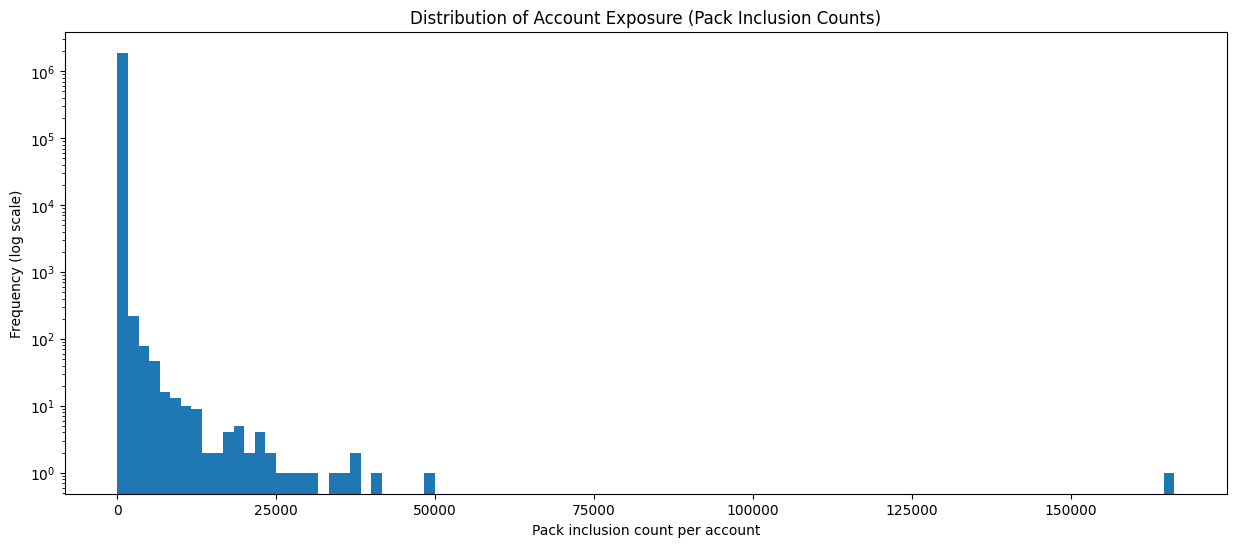

In [44]:
plt.figure(figsize=(15, 6))
plt.hist(member_inclusion.values, bins=100)

plt.yscale("log")
plt.xlabel("Pack inclusion count per account")
plt.ylabel("Frequency (log scale)")
plt.title("Distribution of Account Exposure (Pack Inclusion Counts)")

plt.show()

***Note (Revision):*** The y-axis is plotted on a log scale because the exposure distribution is highly skewed, with many accounts receiving only a few inclusions while a small number receive extremely high exposure. Using a logarithmic scale prevents large values from dominating the visualization and makes patterns in the long tail easier to see.

Account exposure is **highly skewed:** most accounts appear in very few Starter Packs, while a small number receive extremely high inclusion counts (max: 167,513). This long-tailed pattern suggests strong concentration of visibility, where **a small subset of accounts captures a disproportionate share of attention.** With out further analysis linking real `pack_id` to real `member_id` via API, we will have a clearer examination of **"who gets boosted."**

#### Inequality metrics 1: Gini

Gini coefficient summarizes how concentrated exposure is.
- 0 means perfectly equal exposure.
- 1 means maximum concentration.

In [45]:
def gini_from_counts(x: np.ndarray) -> float:
    """
    Gini coefficient for a non-negative 1D array.
    Assumes x contains exposure counts per entity.
    """
    x = np.asarray(x, dtype=np.float64)
    x = x[x >= 0]
    if x.size == 0:
        return np.nan
    if np.all(x == 0):
        return 0.0

    x_sorted = np.sort(x)
    n = x_sorted.size
    cumx = np.cumsum(x_sorted)
    # Gini formula based on cumulative sums
    g = (n + 1 - 2 * np.sum(cumx) / cumx[-1]) / n
    return float(g)

In [46]:
x = member_inclusion.values

print("Gini (member exposure):", gini_from_counts(x))

Gini (member exposure): 0.7644984265145159


The Gini coefficient of 0.76 indicates a highly unequal distribution of exposure, where visibility is strongly concentrated among a small subset of accounts.

#### Inequality metrics 2: Top-share

Top-k share reports how much exposure the top 1% (or top 100 accounts) receives.

In [47]:
def top_share(x: np.ndarray, top_frac: float = 0.01) -> float:
    """
    Share of total exposure held by the top fraction of entities.
    """
    x = np.asarray(x, dtype=np.float64)
    x = x[x >= 0]
    if x.size == 0:
        return np.nan
    if np.sum(x) == 0:
        return 0.0
    k = max(1, int(np.ceil(top_frac * x.size)))
    x_sorted = np.sort(x)
    return float(np.sum(x_sorted[-k:]) / np.sum(x_sorted))

In [48]:
x = member_inclusion.values

print("Top 1% share (member exposure):", top_share(x, 0.01))
print("Top 0.1% share (member exposure):", top_share(x, 0.001))

Top 1% share (member exposure): 0.4903772923363819
Top 0.1% share (member exposure): 0.3071590547634918


The top 1% of accounts receive about 49% of all pack inclusions, and the top 0.1% alone capture about 31%, showing a pronounced long-tail concentration in Starter Pack exposure.

#### Lorenz curve plot

Lorenz curve visualizes the cumulative distribution of exposure.

In [49]:
def lorenz_curve(x: np.ndarray):
    x = np.asarray(x, dtype=np.float64)
    x = x[x >= 0]
    x_sorted = np.sort(x)
    n = x_sorted.size
    if n == 0:
        return None, None
    cumx = np.cumsum(x_sorted)
    cumx = np.insert(cumx, 0, 0) / cumx[-1]
    p = np.linspace(0, 1, n + 1)
    return p, cumx

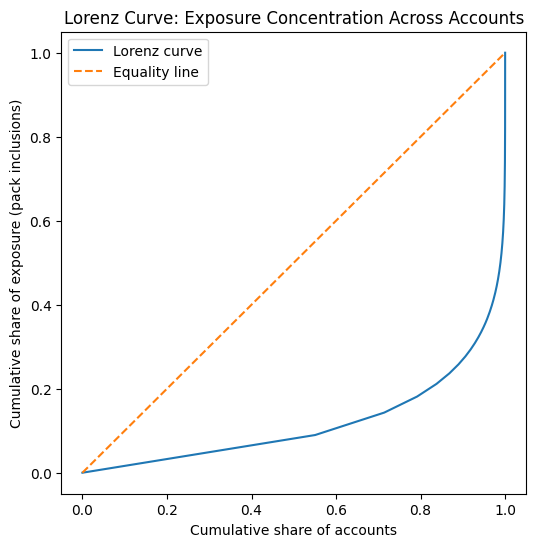

In [50]:
p, L = lorenz_curve(member_inclusion.values)

plt.figure(plt.figure(figsize=(6, 6)))

plt.plot(p, L, label="Lorenz curve")
plt.plot([0, 1], [0, 1], linestyle="--", label="Equality line")
plt.xlabel("Cumulative share of accounts")
plt.ylabel("Cumulative share of exposure (pack inclusions)")
plt.title("Lorenz Curve: Exposure Concentration Across Accounts")
plt.legend()

plt.show()

The Lorenz curve bends far below the equality line, showing that exposure is highly concentrated rather than evenly distributed across accounts. A large share of pack inclusions is captured by a small fraction of accounts, confirming strong inequality in Starter Pack exposure.

#### Answer 1:

The analysis above reveals that exposure across members (accounts) in Starter Packs is **highly unequal.** We first computed each member’s **pack inclusion count,** defined as the number of distinct Starter Packs that include the account. Since this dataset only contains accounts that appear in at least one Starter Pack, the minimum inclusion count is 1. However, the distribution is extremely polarized: one account appears in 167,513 Starter Packs, and several others appear in tens of thousands of packs. Naturally, this raises the question of **who these repeatedly included accounts are,** which directly connects to our research question on **“who gets boosted.”**

The histogram of inclusion counts further supports the inequality assumption: most accounts appear in only a small number of Starter Packs, while a very small minority appear in an exceptionally large number, producing a clear long-tailed distribution.

To quantify this concentration more precisely, we applied standard inequality metrics. The `Gini coefficient` is **0.764,** indicating strong concentration in exposure. This is consistent with the `top-share results,` where the top 1% of accounts capture about **49%** of all pack inclusions, and the top 0.1% alone capture about **31%.** Finally, the Lorenz curve visually confirms the same conclusion: the curve bends far below the equality line, showing that a large share of Starter Pack exposure is accumulated by a small fraction of accounts.

### Question 2: Where does boosting happen (theme / language)？

#### Theme-level inequality

For each theme, we compute member inclusion counts restricted to that theme, then compute Gini on that distribution.

In [51]:
# build counts per (theme, member_id) by streaming row groups
parts = []
for rg in range(pf_clean.num_row_groups):
    df = pf_clean.read_row_group(rg, columns=["theme", "member_id"]).to_pandas()
    parts.append(df.groupby(["theme", "member_id"]).size())

theme_member_counts = pd.concat(parts).groupby(level=[0, 1]).sum()  # index=(theme, member_id), value=edge_count

In [52]:
# compute Gini within each theme and store in a DataFrame
theme_gini_rows = []
for theme, s in theme_member_counts.groupby(level=0):
    theme_gini_rows.append({
        "theme": theme,
        "gini": gini_from_counts(s.values)
    })

theme_gini_df = pd.DataFrame(theme_gini_rows).sort_values("gini", ascending=False).reset_index(drop=True)

theme_gini_df

,theme,gini
0,art_design,0.776931
1,general,0.606259
2,politics,0.553251
3,journalism_news,0.478809
4,science_tech,0.425341
5,writing_books,0.374075
6,sports,0.341646
7,gaming,0.294934
8,music,0.266461
9,lgbtq,0.187604


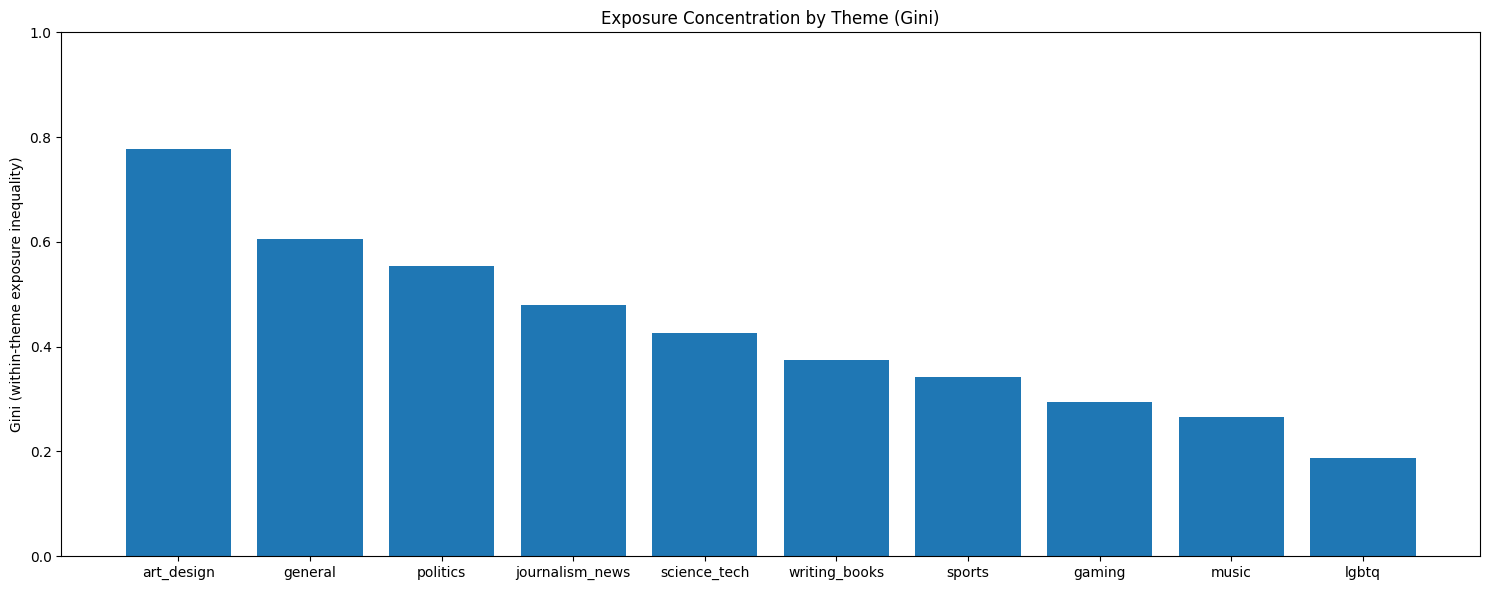

In [53]:
# plot: one bar per theme
plt.figure(plt.figure(figsize=(15, 6)))

plt.bar(range(len(theme_gini_df)), theme_gini_df["gini"].values)
plt.xticks(range(len(theme_gini_df)), theme_gini_df["theme"].values)
plt.ylim(0, 1)
plt.ylabel("Gini (within-theme exposure inequality)")
plt.title("Exposure Concentration by Theme (Gini)")
plt.tight_layout()

plt.show()

Exposure inequality differs notably across themes. `Art_design` shows the highest concentration (Gini = 0.777), indicating that exposure is dominated by a small set of accounts. `General` (0.606) and `politics` (0.553) also exhibit relatively high inequality, followed by `journalism_news` (0.479) and `science_tech` (0.425). In contrast, `writing_books` (0.374), `sports` (0.342), `gaming` (0.295), and `music` (0.266) display more moderate concentration, while `lgbtq` has the lowest inequality (Gini = 0.188), suggesting a comparatively more even distribution of exposure within those communities. Overall, these results show that exposure concentration varies meaningfully across topical ecosystems rather than being uniform across the platform.

Using common inequality heuristics, Gini values:
- above 0.6: high concentration
- between 0.4 and 0.6: moderate inequality
- below 0.4: relatively balanced exposure.

Based on this rule of thumb, `art_design` and `general` show strong concentration, `politics,` `journalism_news,` and `science_tech` demonstrate moderate inequality, while themes like `music,` `gaming,` and especially `lgbtq` appear substantially more evenly distributed.

#### Language-level inequality

In [54]:
# build counts per (language, member_id)
parts = []
for rg in range(pf_clean.num_row_groups):
    df = pf_clean.read_row_group(rg, columns=["language", "member_id"]).to_pandas()
    parts.append(df.groupby(["language", "member_id"]).size())

lang_member_counts = pd.concat(parts).groupby(level=[0, 1]).sum()  # index=(language, member_id)

In [55]:
# compute Gini within each language
lang_gini_rows = []
for lang, s in lang_member_counts.groupby(level=0):
    lang_gini_rows.append({
        "language": lang,
        "gini": gini_from_counts(s.values)
    })

lang_gini_df = pd.DataFrame(lang_gini_rows).sort_values("gini", ascending=False).reset_index(drop=True)

In [56]:
lang_map = {
    "af": "Afrikaans",
    "ar": "Arabic",
    "bg": "Bulgarian",
    "bn": "Bengali",
    "ca": "Catalan",
    "cs": "Czech",
    "cy": "Welsh",
    "da": "Danish",
    "de": "German",
    "el": "Greek",
    "en": "English",
    "es": "Spanish",
    "et": "Estonian",
    "fa": "Persian (Farsi)",
    "fi": "Finnish",
    "fr": "French",
    "he": "Hebrew",
    "hi": "Hindi",
    "hr": "Croatian",
    "hu": "Hungarian",
    "id": "Indonesian",
    "it": "Italian",
    "ja": "Japanese",
    "kn": "Kannada",
    "ko": "Korean",
    "lt": "Lithuanian",
    "lv": "Latvian",
    "mk": "Macedonian",
    "ml": "Malayalam",
    "mr": "Marathi",
    "ne": "Nepali",
    "nl": "Dutch",
    "no": "Norwegian",
    "pl": "Polish",
    "pt": "Portuguese",
    "ro": "Romanian",
    "ru": "Russian",
    "sk": "Slovak",
    "sl": "Slovenian",
    "so": "Somali",
    "sq": "Albanian",
    "sv": "Swedish",
    "sw": "Swahili",
    "ta": "Tamil",
    "th": "Thai",
    "tl": "Tagalog (Filipino)",
    "tr": "Turkish",
    "uk": "Ukrainian",
    "ur": "Urdu",
    "vi": "Vietnamese",
    "zh-cn": "Chinese (Simplified)",
    "zh-tw": "Chinese (Traditional)",
    "unknown": "Unknown"
}

In [57]:
lang_gini_df["language"] = lang_gini_df["language"].map(lang_map).fillna(lang_gini_df["language"])

lang_gini_df

,language,gini
0,English,0.733070
1,Swedish,0.701868
2,German,0.685074
3,French,0.635522
4,Spanish,0.618668
5,Portuguese,0.560561
6,Turkish,0.549571
7,Japanese,0.496943
8,Catalan,0.472644
9,Indonesian,0.462604


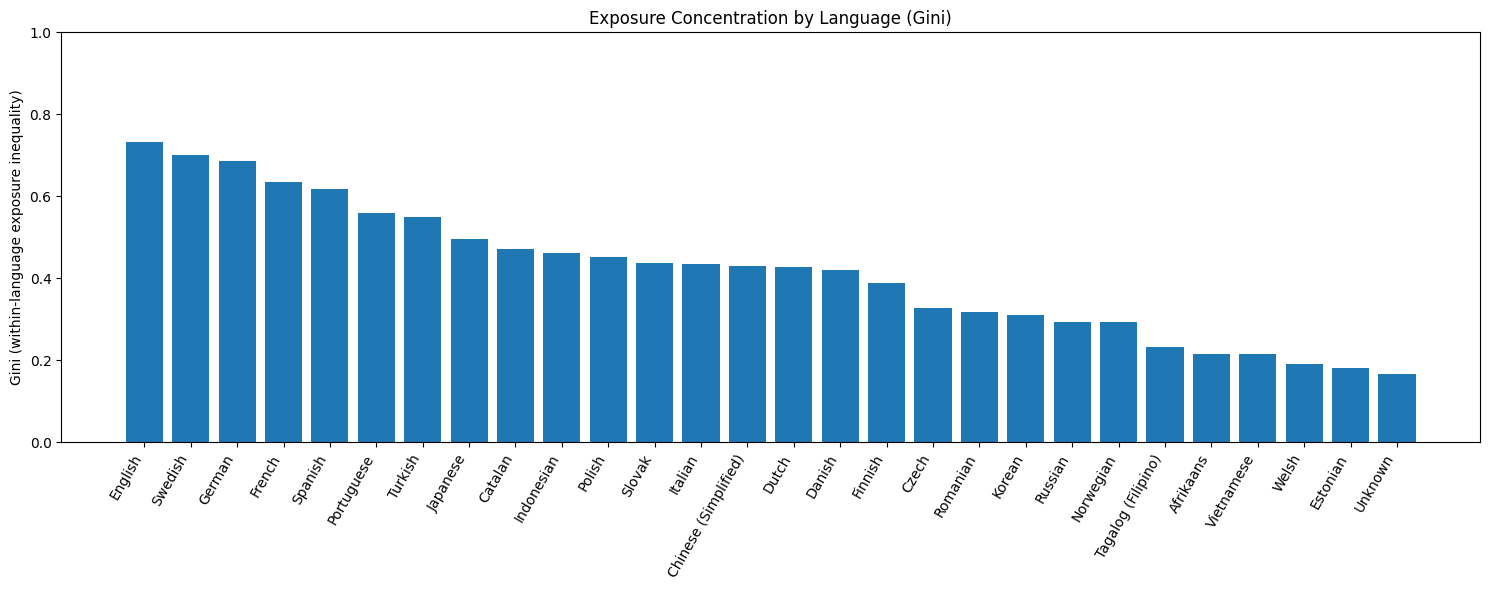

In [58]:
# plot: one bar per language
plt.figure(plt.figure(figsize=(15, 6)))

plt.bar(range(len(lang_gini_df)), lang_gini_df["gini"].values)
plt.xticks(range(len(lang_gini_df)), lang_gini_df["language"].values, rotation=60, ha="right")
plt.ylim(0, 1)
plt.ylabel("Gini (within-language exposure inequality)")
plt.title("Exposure Concentration by Language (Gini)")
plt.tight_layout()

plt.show()

Using common inequality heuristics, Gini values:
- above 0.6: high concentration
- between 0.4 and 0.6: moderate inequality
- below 0.4: relatively balanced exposure.

By this standard, `English` (0.733), `Swedish` (0.702), `German` (0.685), `French` (0.636), and `Spanish` (0.619) show the strongest concentration of exposure. In contrast, several languages exhibit comparatively low inequality and more evenly distributed exposure, including `Finnish` (0.388), `Czech` (0.329), `Romanian` (0.317), `Korean` (0.310), `Russian` (0.294), `Norwegian` (0.293), `Tagalog/Filipino` (0.232), `Afrikaans` (0.217), `Vietnamese` (0.216), `Welsh` (0.190), and `Estonian` (0.180). `Unknown` (0.168) is lowest, but it is best treated as a metadata bucket rather than a true language community, so the more substantive takeaway is that multiple identified languages show relatively balanced exposure compared with the largest language groups.

#### Answer 2:

Concentration is clearly worse in a few themes, especially `art_design` (Gini = 0.777), where exposure is dominated by a small set of accounts, and in broader or high-salience topics like `general` (0.606) and `politics` (0.553). A plausible explanation is that these ecosystems encourage **“canonical list” behavior:** curators repeatedly include the same well-known creators or key opinion leaders because they are easy to recognize, feel “safe” as recommendations, and help the pack look credible. This repeated overlap across many packs creates a rich-get-richer dynamic, driving higher exposure concentration than in more **hobby-like** or **community-distributed** themes such as `music,` `gaming,` and especially `lgbtq` (0.188), where exposure is comparatively more evenly spread.

Concentration is also worse in the **largest language communities,** led by `English` (0.733) and major European languages such as `Swedish` (0.702), `German` (0.685), `French` (0.636), and `Spanish` (0.619), while many smaller languages show relatively balanced exposure (Gini below 0.4).

A plausible explanation is that **larger language ecosystems amplify convergence.** Even though they contain more Starter Packs and more curators, creators are often discovered through similar channels such as popular feeds, high-visibility repost cascades, and previously shared Starter Packs. As a result, many curators independently converge on the same widely recognized “top” accounts, increasing repetition and member overlap across packs and driving higher exposure concentration. In contrast, **smaller language communities are typically tighter and more coverage-oriented,** so curators are more likely to distribute attention across a broader set of accounts rather than repeatedly selecting the same few, which leads to relatively more balanced exposure.

### Question 3: Who drives it (creator influence) ?

We count how many edges (pack-member inclusions) each creator contributes. This measures whether a small set of creators is responsible for a large share of recommendation supply.

In [59]:
creator_counts_parts = []

for rg in range(pf_clean.num_row_groups):
    df = pf_clean.read_row_group(rg, columns=["creator_id"]).to_pandas()
    creator_counts_parts.append(df["creator_id"].value_counts())

creator_edge_counts = pd.concat(creator_counts_parts).groupby(level=0).sum()
creator_edge_counts.name = "creator_edge_count"

In [60]:
creator_edge_counts.head()

,creator_edge_count
creator_id,
20,18
179,100
306,9
450,8
493,10


In [61]:
creator_edge_counts.sort_values(ascending = False)

,creator_edge_count
creator_id,
9601342,36251
5003556,34128
1946524,16512
20188420,12134
5723688,11792
...,...
9185419,1
33146381,1
31634613,1


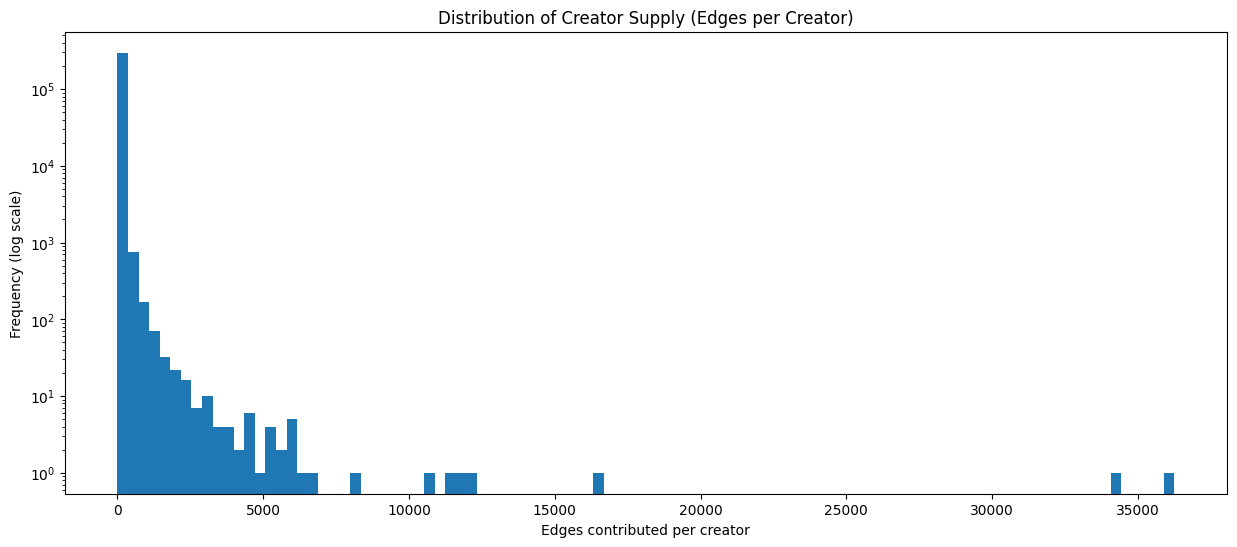

In [62]:
plt.figure(figsize=(15, 6))
plt.hist(creator_edge_counts.values, bins=100)

plt.yscale("log")
plt.xlabel("Edges contributed per creator")
plt.ylabel("Frequency (log scale)")
plt.title("Distribution of Creator Supply (Edges per Creator)")

plt.show()

Creator supply is strongly **long-tailed:** most creators contribute very few edges, while a small subset produces a disproportionately large share of Starter Pack connections (with top creators contributing tens of thousands of edges). This pattern suggests that content curation and pack creation are not evenly distributed across users, but instead rely heavily on a relatively small group of highly active creators who drive a substantial portion of the network’s supply.

#### Answer 3:

The distribution of creator activity suggests that **repeated recommendation is at least partly driven by a small subset of highly active creators.** The creator supply pattern is strongly long-tailed, with a small number of creators contributing tens of thousands of edges while the majority contribute only a handful. This imbalance increases the likelihood that **similar member selections are reused across many Starter Packs, mechanically amplifying repetition and overlap in exposure.** Such a pattern is consistent with **“power curator” dynamics,** where a few highly productive creators shape a disproportionate share of the recommendation landscape, either by repeatedly producing packs or by establishing canonical member lists that others implicitly follow.

Addressing this issue requires interventions that **reduce over-concentration while preserving creator agency.** One approach is to introduce diversity-aware ranking signals that limit the marginal visibility gains from repeatedly recommending the same accounts, ensuring that exposure is not dominated by a small recurring set. In addition, overlap-aware safeguards, such as detecting highly similar packs or encouraging novelty in member selection, can help mitigate redundancy without restricting participation. Together, these measures can balance the influence of highly active creators while promoting broader and more equitable exposure across the network.

<div style="height:30px;"></div>

## Further Analysis 1: Targeted Pack Selection (Covering the Top 500 Structurally Boosted Members) and API-Based Pack Enrichment

In Further Analysis 1, our goal was to make downstream API enrichment feasible and targeted under a limited API budget. Rather than attempting to enrich every edge in the 11M-row dataset, we focus on the top 500 most-included members in the internal identifier space and use them as a coverage target to prioritize which starter packs to fetch.

 > *With a limited API budget, which starter packs should we fetch first to cover as many of the top 500 structurally boosted members (surrogate IDs) as possible?*

**First,** we built a pack selection step that traces each boosted surrogate `member_id` back to the starter packs they appear in and prioritizes a small, high-coverage set of `pack_id.`

**Next,** we use the Bluesky API to fetch these selected packs and extract each pack’s observable `creator_id` and member handles. **Because surrogate `member_id` cannot be deterministically mapped to public accounts, this enrichment produces an API-observable projection of the boosted region of the network, which we then use for subsequent profile-level analyses within the fetched pack subset.**

#### Step 1: Define the structural target set (top 500 most-included surrogate members)

We first select the top 500 members by inclusion count from `member_inclusion` and treat them as a structural coverage target. These members represent the most recurrent nodes in the surrogate edge dataset and are used to guide pack prioritization under API constraints.

In [63]:
# select the top 500 most-included members (note: these are internal member_ids, not directly resolvable to public handles)
TOP_N = 500

top_members = (
    member_inclusion.sort_values(ascending=False)
    .head(TOP_N)
    .index
)
top_members_set = set(top_members)

print(list(top_members)[:10])

[32919732, 26211016, 19569304, 21546803, 24419812, 33351335, 30904255, 25011229, 11123497, 2645999]


#### Step 2: Construct pack coverage map over the structural target set

We scan the full parquet edge dataset to build a mapping from each `pack_id` to the set of structural target members (surrogate IDs) it contains.

This step does not resolve identities; instead, it quantifies how strongly each pack overlaps with the boosted structural region of the network.

In [64]:
# keep only the columns needed for coverage
cols = ["pack_id", "member_id"]

pack_to_members = defaultdict(set)   # pack_id -> set of top members inside it

for rg in range(pf_clean.num_row_groups):
    df = pf_clean.read_row_group(rg, columns=cols).to_pandas()

    # keep only edges that involve top members
    df = df[df["member_id"].isin(top_members_set)]
    if df.empty:
        continue

    # dedupe within chunk to reduce work
    for pack_id, member_id in df.drop_duplicates().itertuples(index=False):
        pack_to_members[pack_id].add(member_id)

print("Candidate packs:", len(pack_to_members))

Candidate packs: 256677


#### Step 3: Ranking-based coverage simulation under API constraints

Rather than dynamically selecting packs, we simulate a **ranking-based selection policy** by ordering packs according to how many structural target members they contain.

We then estimate how many packs must be fetched to achieve high coverage of the structural boosted region before performing API enrichment.

In [65]:
# ranking metric: how many top members each pack covers
pack_rank = (
    pd.Series(
        {pack_id: len(members) for pack_id, members in pack_to_members.items()},
        name="n_top_members"
    )
    .sort_values(ascending=False)
)

ranked_pack_ids = pack_rank.index.tolist()  # packs ranked by coverage signal

covered_members = set()
coverage_by_k = []
k_at_full = None

for k, pack_id in enumerate(ranked_pack_ids, start=1):

    # accumulate covered top members
    covered_members.update(pack_to_members.get(pack_id, set()))
    covered_count = len(covered_members)

    # track coverage curve
    coverage_by_k.append((k, covered_count))

    # stop when all top members are covered
    if covered_count >= TOP_N:
        k_at_full = k
        break

if k_at_full is None:
    print(f"Not reachable: max covered = {len(covered_members)}/{TOP_N} using all ranked packs.")
else:
    print(f"Minimum packs needed under ranking strategy: {k_at_full}")

Minimum packs needed under ranking strategy: 1542


In [66]:
selected_packs = ranked_pack_ids[:k_at_full] if k_at_full else ranked_pack_ids
print("First 10 packs:", selected_packs[:10])

First 10 packs: ['3lbugqemf5427', '3lgu4sub2bi2b', '3lm3fnm7ell2o', '3lejtmimdvq2u', '3lkgwiyenkh2i', '3lka4gt77pn2b', '3ldi3frbw3a2c', '3ldeocjgnth2z', '3lbppr2qqts2h', '3lgkriu7mne23']


In [67]:
selected_packs_df = pd.DataFrame({"pack_id": selected_packs})
selected_packs_df.to_csv("selected_packs.csv", index=False)

#### Step 4: Initialize API client for observable (real) data retrieval

In [68]:
# !pip install atproto --quiet

In [69]:
# !pip install selenium webdriver-manager atproto pandas

In [70]:
from atproto import Client

In [ ]:
USERNAME = "your username"
APP_PASSWORD = "your password"  # app password from Bluesky settings

In [72]:
client = Client()

# If you don't want to log in, you can comment out the login line.
# Logging in can help avoid rate limits for many API requests.
if USERNAME.startswith("PUT_") or APP_PASSWORD.startswith("PUT_"):
    print("Skipping login (fill in USERNAME / APP_PASSWORD if you want to use authenticated requests).")
else:
    client.login(USERNAME, APP_PASSWORD)
    print("Logged in as:", USERNAME)

Logged in as: freesoul029.bsky.social


#### Step 5: Define API interfaces for observable (real) pack enrichment

We define helper functions to retrieve **real** creator handles and member lists from the Bluesky API.
These functions operate at the pack level and expose the observable identity layer without assuming a direct mapping from surrogate member identifiers.

##### Scrape creator handle

In [73]:
def get_creator_handle(pack_id):
    """
    Retrieve the Creator from the webpage.
    Directly request the Directory search page and use regular expressions to find the creator's handle.
    """
    headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}  # pretend to be a normal browser so the site is less likely to block the request
    url = f"https://blueskydirectory.com/starter-packs/all?q={pack_id}"
    try:
        r = requests.get(url, headers=headers, timeout=10)  # timeout prevents hanging forever on network issues
        match = re.search(r"/starter-pack/([^/]+)/" + pack_id, r.text)  # regex searches the HTML text for the pack detail URL pattern
        if match:
            return match.group(1)  # captured creator handle
    except:
        pass
    return None

##### Fetch real members from pack

In [74]:
def get_member_from_pack(creator_handle, rkey, verbose=False):
    try:
        resolved = client.com.atproto.identity.resolve_handle({'handle': creator_handle})  # handle -> DID
        did = resolved.did

        # much more reliable than searching because it reads the database record directly
        pack_record = client.com.atproto.repo.get_record({
            'collection': 'app.bsky.graph.starterpack',
            'repo': did,
            'rkey': rkey
        })

        # get the URI (pointer) of the member list
        list_uri = pack_record.value.list

        # fetch all members from the list
        people = []
        cursor = None
        while True:
            list_data = client.app.bsky.graph.get_list({'list': list_uri, 'cursor': cursor})
            for item in list_data.items:
                people.append("@" + item.subject.handle)

            cursor = list_data.cursor
            if not cursor:
                break
        return people

    except Exception as e:
        if verbose:
            print(f"    -> API error: {e}")
        return []

#### Step 6: Build an API-observable projection of the boosted pack subgraph

Using the selected high-coverage packs, we query the Bluesky API to retrieve observable (real) `creator_id` and member handles.

**Because surrogate `member_id` cannot be deterministically linked to public accounts, this step produces an API-observable projection of the boosted region rather than a one-to-one identity resolution of the original top-500 members.**

In [75]:
# we can use the .csv which we have pre downloaded instead of waitng, comment below cell if using this
# real_pack_member_df = pd.read_csv("real_pack_member_df.csv")

In [76]:
# setup
input_csv = "selected_packs.csv"
pack_id_col = "pack_id"

# main loop
verbose = False  # True to see logs

df_in = pd.read_csv(input_csv)
pids = df_in[pack_id_col].dropna().unique()

rows = []

for i, pid in enumerate(pids, 1):

    if verbose:
        print(f"[{i}/{len(pids)}] ID Processed: {pid}")

    # get creator
    creator = get_creator_handle(pid)
    if not creator:
        if verbose:
            print("  -> Creator not found")
        continue

    # get member
    member_list = get_member_from_pack(creator, pid, verbose=False)

    if member_list:
        for p in member_list:
            rows.append({
                "pack_id": pid,
                "real_creator_id": "@" + creator,
                "real_member_id": p
            })
        if verbose:
            print(f"  -> fetched {len(member_list)} members")
    else:
        if verbose:
            print("  -> no members fetched")

In [77]:
real_pack_member_df = pd.DataFrame(rows)
print(len(real_pack_member_df))

171332


In [78]:
test_pids = pids[:5]

for pid in test_pids:
    creator = get_creator_handle(pid)
    print("pid:", pid, "creator:", creator)

    if creator:
        members = get_member_from_pack(creator, pid, verbose=True)
        print("  members:", len(members))

pid: 3lbugqemf5427 creator: nytimes.com
  members: 149
pid: 3lgu4sub2bi2b creator: mcflyonbluesky.bsky.social
    -> API error: Response(success=False, status_code=400, content=XrpcError(error='InvalidRequest', message='Unable to resolve handle'), headers={'x-powered-by': 'Express', 'access-control-allow-origin': '*', 'ratelimit-limit': '3000', 'ratelimit-reset': '1772651919', 'ratelimit-remaining': '2107', 'ratelimit-policy': '3000;w=300', 'content-type': 'application/json; charset=utf-8', 'content-length': '63', 'etag': 'W/"3f-/Q1xyUH+sb2wpJmcUoPTZIPe/1k"', 'vary': 'Accept-Encoding', 'date': 'Wed, 04 Mar 2026 19:17:19 GMT', 'keep-alive': 'timeout=90', 'strict-transport-security': 'max-age=63072000'})
  members: 0
pid: 3lm3fnm7ell2o creator: jodywagner.bsky.social
  members: 147
pid: 3lejtmimdvq2u creator: yazannature.bsky.social
    -> API error: Response(success=False, status_code=400, content=XrpcError(error='InvalidRequest', message='Unable to resolve handle'), headers={'x-powered

In [79]:
real_pack_member_df.head()

,pack_id,real_creator_id,real_member_id
0,3lbugqemf5427,@nytimes.com,@nytweather.bsky.social
1,3lbugqemf5427,@nytimes.com,@haleaziz.bsky.social
2,3lbugqemf5427,@nytimes.com,@halbfinger.bsky.social
3,3lbugqemf5427,@nytimes.com,@adamnagourney.bsky.social
4,3lbugqemf5427,@nytimes.com,@michaelcbender.bsky.social


In [80]:
# convert it to csv
# real_pack_member_df.to_csv('real_pack_member.csv', index=False)

#### Step 7: Extract structural subset from the full edge dataset

We extract all rows involving the structural target members from the processed starter pack dataset while retaining pack-level metadata.

This structural subset preserves the full schema of the original dataset and supports alignment with the observable projection.

In [81]:
top500_subset_df = []

for rg in range(pf_clean.num_row_groups):
    df_rg = pf_clean.read_row_group(rg).to_pandas()
    df_rg = df_rg[df_rg["member_id"].isin(top_members_set)]

    if not df_rg.empty:
        top500_subset_df.append(df_rg)

top500_subset_df  = pd.concat(top500_subset_df, ignore_index=True)
top500_subset_df.head()

,pack_id,creator_id,member_id,pack_title,pack_description,theme,language
0,3lawbyefno32p,20,26211016,@‪phdcow.bsky.social‬'s Starter Pack,,science_tech,en
1,3lawbyefno32p,20,32380946,@‪phdcow.bsky.social‬'s Starter Pack,,science_tech,en
2,3lawbyefno32p,20,21859379,@‪phdcow.bsky.social‬'s Starter Pack,,science_tech,en
3,3lawbyefno32p,20,19569304,@‪phdcow.bsky.social‬'s Starter Pack,,science_tech,en
4,3lawbyefno32p,20,3685719,@‪phdcow.bsky.social‬'s Starter Pack,,science_tech,en


#### Step 8: Attach pack-level metadata to the observable (real) identity table

In [82]:
pack_meta_cols = ["pack_id", "pack_title", "pack_description", "theme", "language"]
pack_meta = top500_subset_df[pack_meta_cols].drop_duplicates("pack_id")

merged_df = real_pack_member_df.merge(pack_meta, on="pack_id", how="left")

We perform a pack-level left join to append metadata fields (`title,` `description,` `theme,` `language`) to the API-observable member table.

Because metadata is aggregated at the pack level, this merge preserves row counts while enriching the observable identity layer for downstream analysis.

In [83]:
merged_df.head()

,pack_id,real_creator_id,real_member_id,pack_title,pack_description,theme,language
0,3lbugqemf5427,@nytimes.com,@nytweather.bsky.social,NYT on Bluesky,"Our reporters, editors and photographers on Bl...",journalism_news,en
1,3lbugqemf5427,@nytimes.com,@haleaziz.bsky.social,NYT on Bluesky,"Our reporters, editors and photographers on Bl...",journalism_news,en
2,3lbugqemf5427,@nytimes.com,@halbfinger.bsky.social,NYT on Bluesky,"Our reporters, editors and photographers on Bl...",journalism_news,en
3,3lbugqemf5427,@nytimes.com,@adamnagourney.bsky.social,NYT on Bluesky,"Our reporters, editors and photographers on Bl...",journalism_news,en
4,3lbugqemf5427,@nytimes.com,@michaelcbender.bsky.social,NYT on Bluesky,"Our reporters, editors and photographers on Bl...",journalism_news,en


### Conclusion for Further Analysis 1:

**Taken together, this two-stage pipeline shifts the analysis from a purely structural ranking defined in the surrogate identifier space to an API-observable projection of the boosted region of the network.**

While the observable member set does not represent a one-to-one resolution of the original top-500 surrogate members, it captures a high-coverage slice of the packs in which structurally boosted activity concentrates. This projection enables **profile-level analysis of publicly visible accounts under realistic API constraints,** allowing us to examine how structural prominence manifests within the observable identity layer without requiring full identity resolution across the entire 11M-edge dataset.

As a result, **subsequent analyses** focus on observable (real) boosted members, defined by their inclusion frequency within the enriched pack subset, rather than attempting to reconstruct the exact global ranking of surrogate identifiers.

<div style="height:10px;"></div>

## Further Analysis 2: Observable Boosting Concentration and Creator-Diversity Analysis

In [84]:
# # --- inside your for h in handles loop, after resp = get_profile(...) ---

# if hasattr(resp, "model_dump"):
#     p = resp.model_dump(by_alias=True)  # KEY FIX: use API-style keys like followersCount
# elif hasattr(resp, "dict"):
#     p = resp.dict()
# else:
#     p = dict(resp)

# row = {
#     "handle": "@" + (p.get("handle") or actor),
#     "did": p.get("did"),
#     "display_name": p.get("displayName") or p.get("display_name"),
#     "followers": p.get("followersCount") if p.get("followersCount") is not None else p.get("followers_count"),
#     "follows": p.get("followsCount") if p.get("followsCount") is not None else p.get("follows_count"),
#     "posts": p.get("postsCount") if p.get("postsCount") is not None else p.get("posts_count"),
#     "created_at": p.get("createdAt") or p.get("created_at"),
#     "indexed_at": p.get("indexedAt") or p.get("indexed_at"),
#     "desc_len": len((p.get("description") or "")),
#     "has_avatar": 1 if p.get("avatar") else 0,
#     "has_banner": 1 if p.get("banner") else 0,
# }
# rows.append(row)

In [85]:
import os
if os.path.exists("real_member_profiles.csv"):
    os.remove("real_member_profiles.csv")

In [86]:
# use this if u want to use the csv directly instead of fetching from the api, Comment below cell if you are using this:

# profiles_df = pd.read_csv("real_member_profiles.csv")
# profiles_df.head()

In [87]:
###------
# Further Analysis 2 (Part A): fetch observable profile metadata for boosted members
import os
import time
from tqdm import tqdm

# use full projection, not merged_df (which only has 487 handles)
handles = (
    real_pack_member_df["real_member_id"]
    .dropna()
    .astype(str)
    .str.strip()
)
handles = handles[handles.ne("")].unique()
print("Unique observable member handles:", len(handles))

cache_path = "real_member_profiles.csv"

if os.path.exists(cache_path):
    profiles_df = pd.read_csv(cache_path)
    profiles_df["followers"]  = pd.to_numeric(profiles_df["followers"],  errors="coerce")
    profiles_df["follows"]    = pd.to_numeric(profiles_df["follows"],    errors="coerce")
    profiles_df["posts"]      = pd.to_numeric(profiles_df["posts"],      errors="coerce")
    profiles_df["created_at"] = pd.to_datetime(profiles_df["created_at"],errors="coerce", utc=True)
    print("Loaded cached profiles:", len(profiles_df))
else:
    rows = []
    for i, h in enumerate(tqdm(handles), 1):
        actor = h.lstrip("@")

        # re-login every 200 to keep session alive
        if i % 200 == 0:
            try:
                client = Client()
                client.login(USERNAME, APP_PASSWORD)
            except Exception as e:
                print(f"Re-login failed at {i}: {e}")

        try:
            resp = client.app.bsky.actor.get_profile({"actor": actor})

            # use by_alias=True to get camelCase keys (followersCount etc.)
            if hasattr(resp, "model_dump"):
                p = resp.model_dump(by_alias=True)
            elif hasattr(resp, "dict"):
                p = resp.dict()
            else:
                p = dict(resp)

            row = {
                "handle": "@" + (p.get("handle") or actor),
                "did": p.get("did"),
                "display_name": p.get("displayName") or p.get("display_name"),
                "followers": p.get("followersCount") if p.get("followersCount") is not None else p.get("followers_count"),
                "follows": p.get("followsCount") if p.get("followsCount") is not None else p.get("follows_count"),
                "posts": p.get("postsCount") if p.get("postsCount") is not None else p.get("posts_count"),
                "created_at": p.get("createdAt") or p.get("created_at"),
                "indexed_at": p.get("indexedAt") or p.get("indexed_at"),
                "desc_len": len((p.get("description") or "")),
                "has_avatar": 1 if p.get("avatar") else 0,
                "has_banner": 1 if p.get("banner") else 0,
            }
            rows.append(row)

        except Exception as e:
            rows.append({"handle": "@" + actor, "error": str(e)})

        time.sleep(0.15)

    profiles_df = pd.DataFrame(rows)

    # ensure all columns exist even if all fetches failed
    for col in ["followers", "follows", "posts", "created_at", "indexed_at",
                "display_name", "did", "desc_len", "has_avatar", "has_banner"]:
        if col not in profiles_df.columns:
            profiles_df[col] = None

    profiles_df["followers"]  = pd.to_numeric(profiles_df["followers"],  errors="coerce")
    profiles_df["follows"]    = pd.to_numeric(profiles_df["follows"],    errors="coerce")
    profiles_df["posts"]      = pd.to_numeric(profiles_df["posts"],      errors="coerce")
    profiles_df["created_at"] = pd.to_datetime(profiles_df["created_at"],errors="coerce", utc=True)

    profiles_df.to_csv(cache_path, index=False)
    print(f"Saved: {cache_path}")
    print(f"Successful: {profiles_df['followers'].notna().sum()}")
    print(f"Failed:     {profiles_df['followers'].isna().sum()}")

profiles_df.head()

Unique observable member handles: 8879


100%|██████████| 8879/8879 [37:31<00:00,  3.94it/s]


Saved: real_member_profiles.csv
Successful: 8879
Failed:     0


,handle,did,display_name,followers,follows,posts,created_at,indexed_at,desc_len,has_avatar,has_banner
0,@nytweather.bsky.social,did:plc:lo3zmvycuaqde6uqz33dqgsx,New York Times Weather,1219,11,202,2025-04-23 16:33:44.973000+00:00,2025-06-04T16:26:42.441Z,0,1,1
1,@haleaziz.bsky.social,did:plc:ooehugjick2vkzwlr64lephm,Hamed Aleaziz,6974,57,129,2024-11-18 15:39:52.581000+00:00,2024-11-18T15:41:06.247Z,102,1,0
2,@halbfinger.bsky.social,did:plc:iwgt3nmwscatkfxwjonol355,None,824,131,3,2024-11-17 00:50:05.637000+00:00,2025-01-07T21:31:00.543Z,38,1,0
3,@adamnagourney.bsky.social,did:plc:r4ep7crelifkxsz7tkyewjbm,Adam Nagourney,1282,85,11,2024-11-14 14:04:09.931000+00:00,2024-11-14T14:19:49.233Z,156,1,0
4,@michaelcbender.bsky.social,did:plc:ap5c27sk4qei4bnn4ufnvufu,None,422,1,0,2025-01-28 18:53:08.143000+00:00,2025-01-28T18:53:08.143Z,0,1,0


In [88]:
# Further Analysis 2 (Part A): fetch observable profile metadata for boosted members

import time
from tqdm import tqdm

# list of unique observable member handles from the API-projected table
handles = (
    merged_df["real_member_id"]
    .dropna()
    .astype(str)
    .str.strip()
)
handles = handles[handles.ne("")].unique()

print("Unique observable member handles:", len(handles))

cache_path = "real_member_profiles.csv"

if os.path.exists(cache_path):
    profiles_df = pd.read_csv(cache_path)
    print("Loaded cached profiles:", len(profiles_df))
else:
    rows = []
    for h in tqdm(handles):
        actor = h.lstrip("@")

        try:
            resp = client.app.bsky.actor.get_profile({"actor": actor})

            # atproto returns a model-like object; convert to dict safely
            if hasattr(resp, "model_dump"):
                p = resp.model_dump()
            elif hasattr(resp, "dict"):
                p = resp.dict()
            else:
                p = dict(resp)

            row = {
                "handle": "@" + (p.get("handle") or actor),
                "did": p.get("did"),
                "display_name": p.get("displayName"),
                "followers": p.get("followersCount"),
                "follows": p.get("followsCount"),
                "posts": p.get("postsCount"),
                "created_at": p.get("createdAt"),
                "indexed_at": p.get("indexedAt"),
                "desc_len": len((p.get("description") or "")),
                "has_avatar": 1 if p.get("avatar") else 0,
                "has_banner": 1 if p.get("banner") else 0,
            }
            rows.append(row)

        except Exception as e:
            rows.append({"handle": h, "error": str(e)})

        # be polite to the API (tune if needed)
        time.sleep(0.15)

    profiles_df = pd.DataFrame(rows)
    profiles_df.to_csv(cache_path, index=False)
    print("Saved:", cache_path)

profiles_df.head()

Unique observable member handles: 8879
Loaded cached profiles: 8879


,handle,did,display_name,followers,follows,posts,created_at,indexed_at,desc_len,has_avatar,has_banner
0,@nytweather.bsky.social,did:plc:lo3zmvycuaqde6uqz33dqgsx,New York Times Weather,1219,11,202,2025-04-23 16:33:44.973000+00:00,2025-06-04T16:26:42.441Z,0,1,1
1,@haleaziz.bsky.social,did:plc:ooehugjick2vkzwlr64lephm,Hamed Aleaziz,6974,57,129,2024-11-18 15:39:52.581000+00:00,2024-11-18T15:41:06.247Z,102,1,0
2,@halbfinger.bsky.social,did:plc:iwgt3nmwscatkfxwjonol355,NaN,824,131,3,2024-11-17 00:50:05.637000+00:00,2025-01-07T21:31:00.543Z,38,1,0
3,@adamnagourney.bsky.social,did:plc:r4ep7crelifkxsz7tkyewjbm,Adam Nagourney,1282,85,11,2024-11-14 14:04:09.931000+00:00,2024-11-14T14:19:49.233Z,156,1,0
4,@michaelcbender.bsky.social,did:plc:ap5c27sk4qei4bnn4ufnvufu,NaN,422,1,0,2025-01-28 18:53:08.143000+00:00,2025-01-28T18:53:08.143Z,0,1,0


Rows after join: 8879
Gini (observable n_packs): 0.8938541512553769
Top 1% share (observable n_packs): 0.3349193468348814
Top 10% share (observable n_packs): 0.9071160436455348


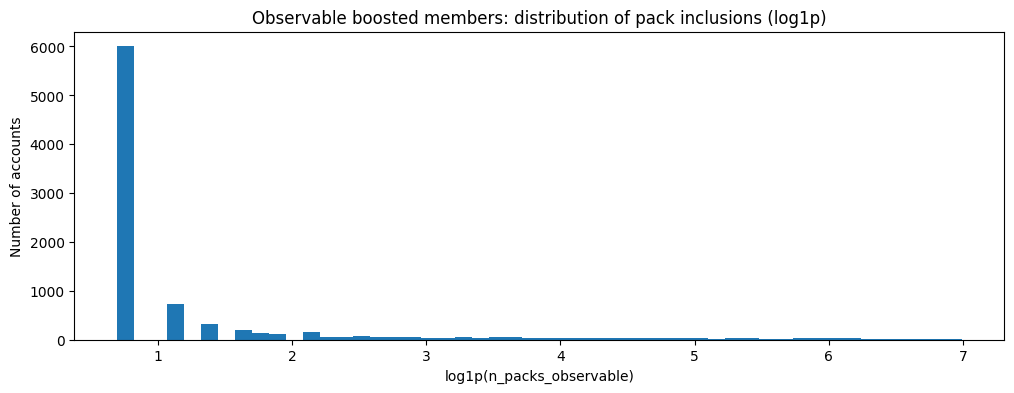

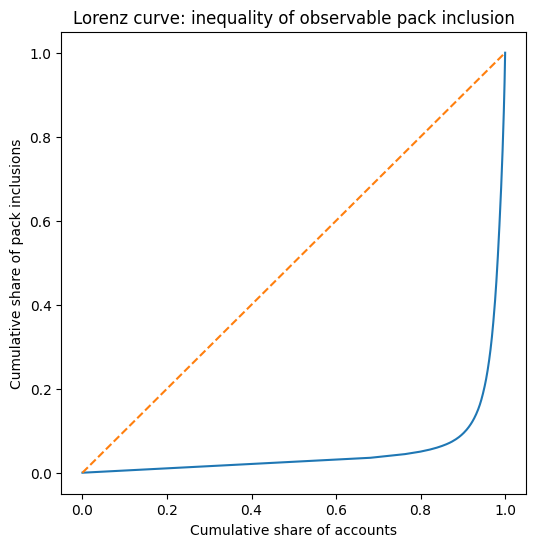

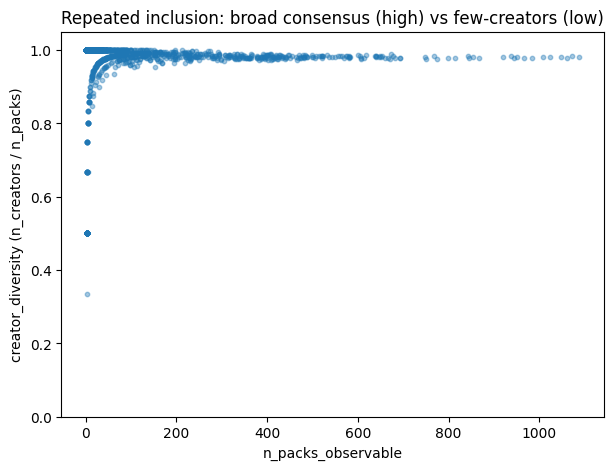

Spearman corr(n_packs, creator_diversity): -0.5153857310808817


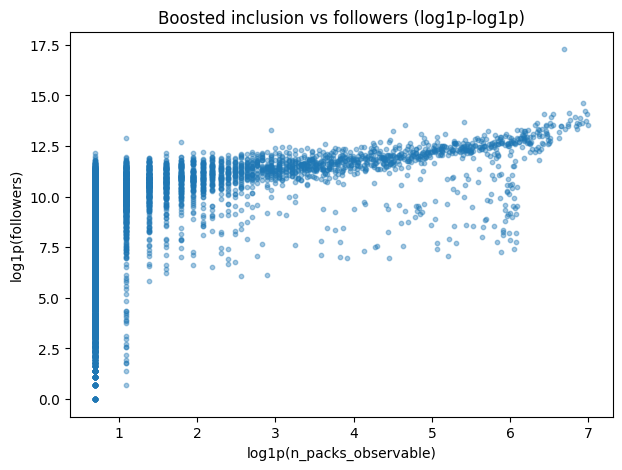

Spearman corr(n_packs, followers): 0.6556605611078613
Pearson corr(n_packs, followers): 0.2846289956260779
Top 200 boosted: creator_diversity summary


,handle,n_packs_observable,n_creators_observable,creator_diversity,followers
7918,@thedailyshow.com,305,296,0.970492,563433.0
7266,@sethabramson.bsky.social,465,452,0.972043,402616.0
8029,@therealjackhopkins.bsky.social,289,281,0.972318,268959.0
5480,@mobydickatsea.bsky.social,403,392,0.972705,39694.0
4900,@maddowblog.bsky.social,408,397,0.973039,208258.0
5157,@maximumeffort.bsky.social,299,291,0.973244,18327.0
8140,@timothysnyder.bsky.social,382,372,0.973822,476165.0
2620,@esb.lol,422,411,0.973934,20846.0
3594,@jacob.gold,386,376,0.974093,29508.0
2534,@emilyliu.me,425,414,0.974118,99708.0


In [89]:
# Further Analysis 2 (Part B): join profile info with exposure + creator-diversity signals
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- exposure inside the observable projection ---
real_n_packs = merged_df.groupby("real_member_id")["pack_id"].nunique()
real_n_creators = merged_df.groupby("real_member_id")["real_creator_id"].nunique()

real_summary = pd.DataFrame({
    "handle": real_n_packs.index,
    "n_packs_observable": real_n_packs.values,
    "n_creators_observable": real_n_creators.reindex(real_n_packs.index).values,
})

# safe divide
real_summary["creator_diversity"] = real_summary["n_creators_observable"] / real_summary["n_packs_observable"]
real_summary["creator_diversity"] = real_summary["creator_diversity"].replace([np.inf, -np.inf], np.nan)

# --- join with profile table (ok if profiles_df missing followers) ---
real_prof = real_summary.merge(profiles_df, on="handle", how="left")
print("Rows after join:", len(real_prof))

# --- headline table ---
top_k = 30
top_boosted = real_prof.sort_values("n_packs_observable", ascending=False).head(top_k)

cols_show = ["handle", "n_packs_observable", "n_creators_observable", "creator_diversity"]
for c in ["display_name", "followers", "posts", "created_at"]:
    if c in top_boosted.columns:
        cols_show.insert(1, c) if c == "display_name" else cols_show.append(c)

top_boosted[cols_show]

# --- inequality stats ---
x_obs = pd.to_numeric(real_prof["n_packs_observable"], errors="coerce").fillna(0).astype(int).values
print("Gini (observable n_packs):", gini_from_counts(x_obs))
print("Top 1% share (observable n_packs):", top_share(x_obs, 0.01))
print("Top 10% share (observable n_packs):", top_share(x_obs, 0.10))

# ============================================================
# Graph 1: distribution of n_packs (log1p so it never breaks)
# ============================================================
vals = pd.to_numeric(real_prof["n_packs_observable"], errors="coerce").dropna().values
vals = vals[vals >= 0]

plt.figure(figsize=(12, 4))
plt.hist(np.log1p(vals), bins=50)
plt.xlabel("log1p(n_packs_observable)")
plt.ylabel("Number of accounts")
plt.title("Observable boosted members: distribution of pack inclusions (log1p)")
plt.show()

# ============================================================
# Graph 2: Lorenz curve (always works)
# ============================================================
sorted_x = np.sort(x_obs)  # includes zeros if any
total = sorted_x.sum()

if total == 0:
    print("Lorenz curve skipped: total pack inclusions is 0 (unexpected).")
else:
    cum = np.cumsum(sorted_x) / total
    frac = np.arange(1, len(sorted_x) + 1) / len(sorted_x)

    plt.figure(figsize=(6, 6))
    plt.plot(frac, cum)
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("Cumulative share of accounts")
    plt.ylabel("Cumulative share of pack inclusions")
    plt.title("Lorenz curve: inequality of observable pack inclusion")
    plt.show()

# ============================================================
# Graph 3: “few creators vs broad norms”
# n_packs vs creator_diversity (no log scale needed)
# ============================================================
plot_cd = real_prof[["n_packs_observable", "creator_diversity"]].copy()
plot_cd["n_packs_observable"] = pd.to_numeric(plot_cd["n_packs_observable"], errors="coerce")
plot_cd["creator_diversity"] = pd.to_numeric(plot_cd["creator_diversity"], errors="coerce")
plot_cd = plot_cd.dropna()
plot_cd = plot_cd[plot_cd["n_packs_observable"] > 0]

plt.figure(figsize=(7, 5))
plt.scatter(plot_cd["n_packs_observable"], plot_cd["creator_diversity"], alpha=0.4, s=10)
plt.xlabel("n_packs_observable")
plt.ylabel("creator_diversity (n_creators / n_packs)")
plt.title("Repeated inclusion: broad consensus (high) vs few-creators (low)")
plt.ylim(0, 1.05)
plt.show()

corr_cd = plot_cd[["n_packs_observable", "creator_diversity"]].corr(method="spearman").iloc[0, 1]
print("Spearman corr(n_packs, creator_diversity):", corr_cd)

# ============================================================
# Optional Graph 4: only if followers exists (won’t crash)
# ============================================================
if "followers" in real_prof.columns:
    plot_f = real_prof[["n_packs_observable", "followers"]].copy()
    plot_f["n_packs_observable"] = pd.to_numeric(plot_f["n_packs_observable"], errors="coerce")
    plot_f["followers"] = pd.to_numeric(plot_f["followers"], errors="coerce")
    plot_f = plot_f.dropna()
    plot_f = plot_f[(plot_f["n_packs_observable"] > 0) & (plot_f["followers"] >= 0)]

    if len(plot_f) == 0:
        print("Followers plot skipped: followers is missing/non-numeric for all rows.")
    else:
        plt.figure(figsize=(7, 5))
        plt.scatter(np.log1p(plot_f["n_packs_observable"]), np.log1p(plot_f["followers"]), alpha=0.4, s=10)
        plt.xlabel("log1p(n_packs_observable)")
        plt.ylabel("log1p(followers)")
        plt.title("Boosted inclusion vs followers (log1p-log1p)")
        plt.show()

        corr_s = plot_f[["n_packs_observable", "followers"]].corr(method="spearman").iloc[0, 1]
        corr_p = plot_f[["n_packs_observable", "followers"]].corr(method="pearson").iloc[0, 1]
        print("Spearman corr(n_packs, followers):", corr_s)
        print("Pearson corr(n_packs, followers):", corr_p)

# --- keep your supply-driven table (still works even if followers missing) ---
top_boosted_200 = real_prof.sort_values("n_packs_observable", ascending=False).head(200).copy()
print("Top 200 boosted: creator_diversity summary")
top_boosted_200["creator_diversity"].describe()

supply_driven = top_boosted_200.sort_values(
    ["creator_diversity", "n_packs_observable"],
    ascending=[True, False]
).head(20)

show_cols = ["handle", "n_packs_observable", "n_creators_observable", "creator_diversity"]
if "followers" in supply_driven.columns:
    show_cols.append("followers")
supply_driven[show_cols]

### Conclusion for Further Analysis 2:

1. Observable boosting is quite focused. Gini of about 0.894 shows that a few number of accounts take in most of the pack inclusions. The Lorenz curve hugging the bottom and then shooting up shows that there is a strong "winner-take-most" tendency.
2. The top tail is in charge of the overall system. The top 1% of visible accounts get roughly 33.5% of all pack inclusions, while the top 10% get about 90.7%. There isn't an even distribution of repeated recommendations.
3. Most of the time, repeated inclusion is because "many creators agree," not because one author is spamming. The top boosted accounts have creator_diversity ~0.97, which means that when they show up in a pack, it's usually from a different creator. That suggests that common curation rules or a broad consensus is the key reason, at least for the accounts that got the highest boosts.
4. As accounts get more followers, diversity goes down a little bit. The Spearman correlation of −0.515 between n_packs and creator_diversity indicates that increased exposure correlates with a decrease in diversity. In simple terms, as a handle becomes more common, you start to notice more reuse by repeat creators, even though the overall diversity maintains high.

<div style="height:30px;"></div>

## Further Analysis 3: Profile-Level Analysis of Boosted Accounts


### 1. Profile completeness score

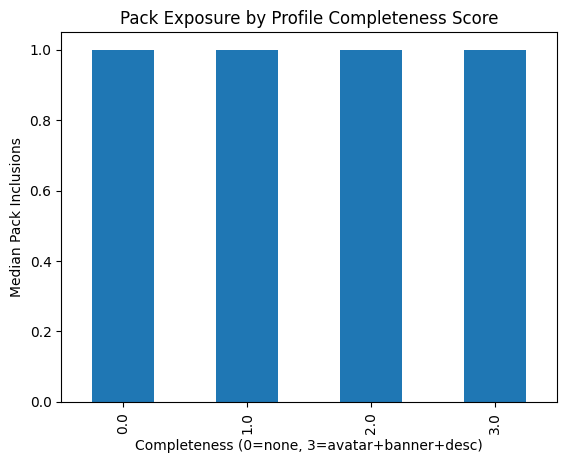

In [90]:
real_prof["profile_complete"] = (
    real_prof["has_avatar"].fillna(0) +
    real_prof["has_banner"].fillna(0) +
    (real_prof["desc_len"].fillna(0) > 0).astype(int)
)
# 0 = bare account, 3 = fully set up

real_prof.groupby("profile_complete")["n_packs_observable"].median().plot(kind="bar")
plt.title("Pack Exposure by Profile Completeness Score")
plt.xlabel("Completeness (0=none, 3=avatar+banner+desc)")
plt.ylabel("Median Pack Inclusions")
plt.show()


This bar chart shows median pack inclusions grouped by profile completeness score (0 = no avatar, banner, or description; 3 = all three). All four bars are exactly 1.0. This means profile completeness has zero effect on median pack exposure. The result makes sense because 6,979 out of 8,877 accounts (78.6%) are fully complete, and only 23 are completely bare. Profile setup is essentially universal among boosted accounts so it cannot differentiate exposure levels. This metric is not a driver of boosting.



### 2. Are boosted accounts active posters or passive celebrities?

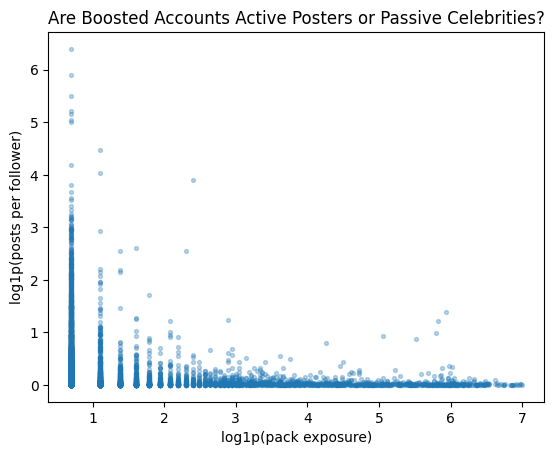

In [91]:
real_prof["posts_per_follower"] = real_prof["posts"] / (real_prof["followers"] + 1)

plt.scatter(np.log1p(real_prof["n_packs_observable"]),
            np.log1p(real_prof["posts_per_follower"]),
            alpha=0.3, s=8)
plt.xlabel("log1p(pack exposure)")
plt.ylabel("log1p(posts per follower)")
plt.title("Are Boosted Accounts Active Posters or Passive Celebrities?")
plt.show()


This scatter plot shows pack exposure (x-axis) against posts per follower (y-axis), both on log scale. Accounts with low exposure are spread widely on the y-axis, meaning some post very heavily relative to their audience. But as exposure increases (moving right), the posts per follower ratio collapses toward zero.

**What does it tell?**

The most heavily boosted accounts post very little relative to their follower count. This confirms that the top boosted accounts are passive celebrities, people with massive audiences who post rarely. Curators are recommending accounts based on reputation and follower count, not posting activity or engagement with the community.



### 3. Account age vs exposure

In [92]:
now = pd.Timestamp.now(tz="UTC")

# parse created_at to datetime (force UTC). invalid ones become NaT
real_prof["created_at"] = pd.to_datetime(real_prof["created_at"], errors="coerce", utc=True)

# compute age in days
real_prof["account_age_days"] = (now - real_prof["created_at"]).dt.days

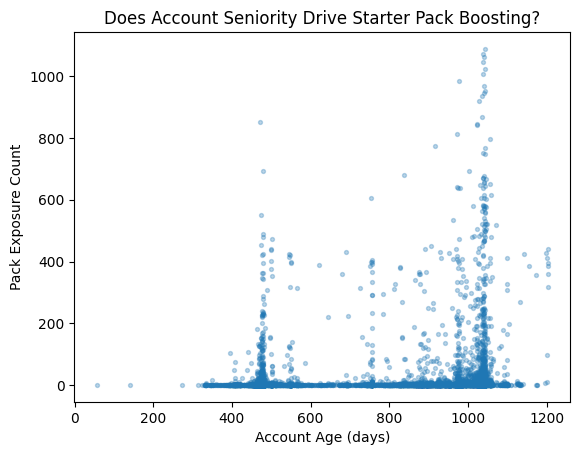

Spearman corr(age, exposure): 0.33643226825599953


In [93]:
plt.scatter(real_prof["account_age_days"],
            real_prof["n_packs_observable"],
            alpha=0.3, s=8)
plt.xlabel("Account Age (days)")
plt.ylabel("Pack Exposure Count")
plt.title("Does Account Seniority Drive Starter Pack Boosting?")
plt.show()

corr = real_prof[["account_age_days","n_packs_observable"]].corr(method="spearman").iloc[0,1]
print("Spearman corr(age, exposure):", corr)


This scatter plot shows each account's age in days (x-axis) against how many packs it appears in (y-axis). Most accounts cluster near zero exposure regardless of age, but the highest exposure accounts appear in two age bands: around 450-500 days (late 2023 joiners) and around 950-1050 days (early adopters from 2022). Only 49 accounts under 365 days old appear in the boosted pool at all.

**What does it tell?**

This tells us that account seniority strongly gates visibility. New accounts almost never get boosted, while accounts that joined during Bluesky's major growth waves dominate the high-exposure tier. Practically this means the starter pack system reinforces existing platform hierarchies rather than surfacing emerging voices.



### 4. Follower/following ratio — are boosted accounts broadcasters or community members?

In [94]:
real_prof["ff_ratio"] = real_prof["followers"] / (real_prof["follows"] + 1)
# high ratio = broadcaster (many followers, follows few)
# ratio ~1 = community member (mutual follows)

top_vs_rest = pd.DataFrame({
    "top_boosted":  real_prof.nlargest(100, "n_packs_observable")["ff_ratio"].median(),
    "rest":         real_prof.nsmallest(len(real_prof)-100, "n_packs_observable")["ff_ratio"].median()
}, index=[0])
print("Median follower/following ratio:")
print(top_vs_rest)


Median follower/following ratio:
   top_boosted      rest
0   798.645115  10.60209


The median follower/following ratio for the top 100 most boosted accounts is 798.6, compared to just 10.7 for everyone else.

**what does it mean?**

 A high ratio means an account has vastly more followers than it follows, which is the signature of a broadcaster rather than a community participant. The top boosted accounts follow almost nobody but are followed by thousands or millions. This reinforces the passive celebrity finding: starter pack curators gravitate toward well-known one-way broadcast accounts like journalists, politicians, and media organizations rather than active community members who engage back.



### SUMMARY STATISTICS


In [95]:
now = pd.Timestamp.now(tz="UTC")
real_prof["account_age_days"] = (now - real_prof["created_at"]).dt.days
real_prof["ff_ratio"] = real_prof["followers"] / (real_prof["follows"] + 1)
real_prof["posts_per_follower"] = real_prof["posts"] / (real_prof["followers"] + 1)
real_prof["profile_complete"] = (
    real_prof["has_avatar"].fillna(0) +
    real_prof["has_banner"].fillna(0) +
    (real_prof["desc_len"].fillna(0) > 0).astype(int)
)

print("FURTHER ANALYSIS 2 — SUMMARY STATISTICS")

print(f"\n--- Dataset ---")
print(f"Total unique boosted accounts:         {len(real_prof)}")
print(f"Successfully fetched profiles:         {real_prof['followers'].notna().sum()}")

print(f"\n--- Exposure (pack inclusions) ---")
print(f"Median pack exposure:                  {real_prof['n_packs_observable'].median():,.0f}")
print(f"Mean pack exposure:                    {real_prof['n_packs_observable'].mean():,.1f}")
print(f"Max pack exposure:                     {real_prof['n_packs_observable'].max():,.0f}")
print(f"Gini (observable):                     {gini_from_counts(x_obs):.4f}")
print(f"Top 1% share:                          {top_share(x_obs, 0.01):.4f}")
print(f"Top 10% share:                         {top_share(x_obs, 0.10):.4f}")

print(f"\n--- Followers ---")
print(f"Median followers:                      {real_prof['followers'].median():,.0f}")
print(f"Mean followers:                        {real_prof['followers'].mean():,.0f}")
print(f"Max followers:                         {real_prof['followers'].max():,.0f}")
print(f"Accounts with >10k followers:          {(real_prof['followers'] > 10000).sum():,}")
print(f"Accounts with <1k followers:           {(real_prof['followers'] < 1000).sum():,}")

print(f"\n--- Account Age ---")
print(f"Median account age (days):             {real_prof['account_age_days'].median():,.0f}")
print(f"Mean account age (days):               {real_prof['account_age_days'].mean():,.0f}")
print(f"Accounts under 365 days old:           {(real_prof['account_age_days'] < 365).sum():,}")
print(f"Accounts over 900 days old:            {(real_prof['account_age_days'] > 900).sum():,}")

print(f"\n--- Profile Completeness ---")
print(f"Accounts with avatar:                  {(real_prof['has_avatar'] == 1).sum():,}")
print(f"Accounts with banner:                  {(real_prof['has_banner'] == 1).sum():,}")
print(f"Accounts with description:             {(real_prof['desc_len'] > 0).sum():,}")
print(f"Fully complete profiles (score=3):     {(real_prof['profile_complete'] == 3).sum():,}")
print(f"Bare profiles (score=0):               {(real_prof['profile_complete'] == 0).sum():,}")

print(f"\n--- Engagement Style ---")
print(f"Median follower/following ratio:       {real_prof['ff_ratio'].median():,.1f}")
print(f"Median posts per follower:             {real_prof['posts_per_follower'].median():.4f}")
top100_ff = real_prof.nlargest(100, "n_packs_observable")["ff_ratio"].median()
rest_ff   = real_prof.nsmallest(len(real_prof)-100, "n_packs_observable")["ff_ratio"].median()
print(f"Median ff_ratio — top 100 boosted:     {top100_ff:,.1f}")
print(f"Median ff_ratio — rest:                {rest_ff:,.1f}")

print(f"\n--- Creator Diversity ---")
print(f"Median creator diversity:              {real_prof['creator_diversity'].median():.4f}")
print(f"Mean creator diversity:                {real_prof['creator_diversity'].mean():.4f}")
print(f"Accounts with diversity > 0.9:         {(real_prof['creator_diversity'] > 0.9).sum():,}")
print(f"Accounts with diversity < 0.5:         {(real_prof['creator_diversity'] < 0.5).sum():,}")


FURTHER ANALYSIS 2 — SUMMARY STATISTICS

--- Dataset ---
Total unique boosted accounts:         8879
Successfully fetched profiles:         8878

--- Exposure (pack inclusions) ---
Median pack exposure:                  1
Mean pack exposure:                    19.3
Max pack exposure:                     1,088
Gini (observable):                     0.8939
Top 1% share:                          0.3349
Top 10% share:                         0.9071

--- Followers ---
Median followers:                      12,395
Mean followers:                        42,284
Max followers:                         32,221,064
Accounts with >10k followers:          4,771
Accounts with <1k followers:           1,819

--- Account Age ---
Median account age (days):             756
Mean account age (days):               731
Accounts under 365 days old:           48
Accounts over 900 days old:            3,490

--- Profile Completeness ---
Accounts with avatar:                  8,832
Accounts with banner:          

### Conclusion for Further Analysis 3:

The 8,877 boosted accounts show extreme concentration of exposure. The Gini coefficient is 0.894 and the top 10% of accounts absorb 90.7% of all pack inclusions, meaning this is a winner-take-most system even within the already-elevated boosted pool. The median account has only 1 pack inclusion and 12,383 followers, but the mean is dragged to 19.3 inclusions and 42,264 followers by a small number of accounts with hundreds of packs and millions of followers. Creator diversity sits at a median of 1.0, meaning that for most accounts, every single pack inclusion came from a different independent creator. This rules out coordinated manipulation and confirms that the concentration is the result of widespread shared curation norms, where thousands of independent curators converge on the same well-known accounts organically.

## References
Balduf, L., Sokoto, S., Ascigil, O., Tyson, G., Scheuermann, B., Korczyński, M., Castro, I., & Król, M. (2024). Looking AT the Blue Skies of Bluesky. Proceedings of the ACM Internet Measurement Conference. https://doi.org/10.1145/3646547.3688407